# 고향관광 기획안 — EDA & 모델링 노트북

**연고 기반 방문객 전환 정책을 위한 2025년 국민여행조사 분석**

이 노트북은 `고향관광_기획안.md`에서 설계한 EDA(2장)와 로지스틱 회귀(3장)를 실제 데이터로 수행합니다.
원본 계획을 그대로 옮기지 않고, 데이터 구조를 먼저 검증한 뒤 **실행 불가능하거나 편향 위험이 있는 부분은 대체 변수로 수정**하고,
기획안의 정책 논리를 더 뒷받침할 수 있는 분석을 추가했습니다. 무엇을 왜 바꿨는지는 1장과 각 섹션의 노트에 명시합니다.

## 원기획안 대비 바뀐 점 요약

| 구분 | 원기획안 계획 | 이 노트북에서의 처리 | 이유 |
|---|---|---|---|
| 지출 격차 (분석2) | `NA8`(1인당 총지출) 등 A8 세부 항목으로 비교 | `D_TRA*_COST`/`D_TRA*_ONE_COST`(여행 차수별 총경비/1인지출)로 비교 | `NA8`을 포함한 A1~A12·D1 세부 문항은 **관광/휴양 활동이 포함된 여행(유형 1·2·4)에만 응답**되고 유형 3(단순방문)은 구조적으로 89%가 결측이라, 유형 간 평균 비교에 쓰면 생존자 편향이 생김 (1장에서 실증) |
| 숙박·활동 누수 (분석3) | 숙박 누수 + "활동 참여율" 두 가지 | 숙박 누수는 유지, "활동 참여율"은 축소(유형3은 정의상 활동 0%라 동어반복) → **유형1 vs 2의 활동 프로필 비교**로 대체 | 유형 3은 애초에 "관광활동 미포함"이 정의라서 참여율 격차가 발견이 아니라 정의의 재확인임 |
| 로지스틱 회귀 (3장) | 독립변수에 동반자 유형(`A6B_7` 친구동반 등) 포함 | 주 모형에서는 제외하고 `D_TRA*_NUM`(일행수)으로 대체, `A6B_7`은 A-series가 존재하는 부표본에 한해 탐색적 보조모형으로만 사용 | `A6B_*`도 A-series 결측 문제를 그대로 가지고 있어(유형3의 97%가 결측) 전체 표본 모형에 넣으면 사실상 유형3 관측치가 사라짐 |
| 모델 진단 | 오즈비 해석까지만 명시 | McFadden 의사 R², AUC, 혼동행렬, 응답자 ID 클러스터 표준오차 추가 | 한 응답자가 여러 여행(행)을 제공하므로 관측치 간 독립성이 깨짐 — 군집 표준오차로 보정 |
| 계절성 | 없음 | 연고 방문의 월별(명절 집중도) 분석 추가 | 기획안 1.3절이 "명절 귀성"을 핵심 서사로 들면서도 정작 EDA에서 계절성을 확인하지 않음 |
| 인구감소지역 89곳 | "색상으로 오버레이"라고만 언급 | 행정안전부 고시 제2021-66호 기준 89개 시군구 명단을 직접 코딩해 반영 | 사분면 분석(분석4)의 핵심 오버레이 근거 |
| 표본 안정성 | 점 크기만 반영 | 최소 표본 수 미만 시군구는 사분면에서 별도 표시(속이 빈 마커) 처리 | 표본이 극히 적은 시군구가 우연히 극단값에 찍혀 "최우선 타겟"으로 오인되는 것을 방지 |
| 방문지 지역 코드 | SPSS 값 라벨(`D_TRA*_SPOT`)을 그대로 매핑 | `national_travel_survey_region_code.csv`(시도_코드+시군구_코드) 공식 코드표로 직접 매핑 — SPOT = 시도코드(2자리)*1000 + 시군구코드(3자리) | 이 SAV 파일의 SPOT 값 라벨 메타데이터가 EUC-KR 인코딩 손상(mojibake)으로 깨져 있어 그대로 쓰면 지역명이 전부 깨짐. 겸사겸사 시도명 축약 로직(`_norm_sido`)이 접미사만 떼는 방식이라 충청북도→충청북처럼 `DECLINING_REGIONS`의 축약 키(충북 등)와 어긋나 인구감소지역 판정이 틀렸던 부분도 명시적 매핑 테이블로 수정 |

In [ ]:
from pathlib import Path
import sys


current_directory = Path.cwd().resolve()
project_root = next(
    (
        candidate
        for candidate in (current_directory, *current_directory.parents)
        if (candidate / "src" / "path.py").is_file()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError(
        "프로젝트 루트를 찾을 수 없습니다. 프로젝트 내부에서 실행하세요."
    )
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.path import (  # noqa: E402
    NOTEBOOKS_DIR,
    OUTPUTS_DIR,
    NATIONAL_TRAVEL_SURVEY_RAW_DATA_DIR,
    PROJECT_ROOT,
    RAW_DATA_DIR,
)


ROOT = PROJECT_ROOT

## 0. 환경설정 및 데이터 로드

**왜 `.xlsx`가 아니라 `.SAV`를 쓰는가**: 제공된 `.xlsx` 원자료는 내부 시트 하나가 압축 해제 시 약 3.1GB에 달해 `openpyxl`/표준 XML 파서로는 사실상 열리지 않는다(대용량 XML에서 파서 오버플로 발생 확인).
동일한 원자료의 `.SAV`(SPSS) 파일은 약 177MB로 훨씬 가볍고, 값 라벨(코드→한글명 매핑)이 메타데이터에 이미 내장되어 있어 `variable_code.md`의 코드북을 그대로 신뢰할 수 있다. 이 노트북은 `.SAV`를 원본으로 사용한다.

전체 2,419개 컬럼 중 이 분석에 필요한 컬럼만 선택적으로 로드해 메모리를 절약한다.

In [1]:
import numpy as np
import pandas as pd
import pyreadstat
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

DATA_PATH = (
    NATIONAL_TRAVEL_SURVEY_RAW_DATA_DIR
    / "y2025"
    / "2025년_국민여행조사_국내여행.SAV"
)

In [2]:
# ---- 시각화 스타일: dataviz 팔레트(고정 순서 카테고리컬 8색 + 상태색) 적용 ----
plt.rcParams['font.family'] = 'Malgun Gothic'      # Windows 한글 폰트
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.facecolor'] = '#fcfcfb'
plt.rcParams['axes.facecolor'] = '#fcfcfb'
plt.rcParams['axes.edgecolor'] = '#c3c2b7'
plt.rcParams['axes.labelcolor'] = '#0b0b0b'
plt.rcParams['text.color'] = '#0b0b0b'
plt.rcParams['xtick.color'] = '#52514e'
plt.rcParams['ytick.color'] = '#52514e'
plt.rcParams['grid.color'] = '#e1e0d9'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 11

CAT_COLORS = ['#2a78d6', '#1baf7a', '#eda100', '#008300', '#4a3aa7', '#e34948', '#e87ba4', '#eb6834']
GOOD, WARNING, SERIOUS, CRITICAL = '#0ca30c', '#fab219', '#ec835a', '#d03b3b'
MUTED, BASELINE = '#898781', '#c3c2b7'

# 여행유형(CASE) 고정 색상 — 노트북 전체에서 동일 유형은 항상 동일 색
CASE_LABELS = {
    1: '1.순수관광',
    2: '2.연고방문+관광',
    3: '3.단순연고방문',
    4: '4.출장+관광',
    5: '5.단순출장',
}
CASE_COLORS = {1: CAT_COLORS[0], 2: CAT_COLORS[1], 3: CAT_COLORS[2], 4: CAT_COLORS[3], 5: MUTED}

## 1. 데이터 구조 검증: 원기획안을 수정하게 만든 핵심 발견

기획안 2.2절은 `NA8`(1인당 지출), `A4_*`(참여활동), `A6B_*`(동반자 구성) 등을 여행유형(CASE) 2번·3번 비교에 바로 쓸 수 있다고 가정한다.
그러나 이 변수들은 국민여행조사 설문지 구조상 **"A1~A12, D1" 문항 묶음**(패키지 구매, 사전예약, 참여활동, 동반자, 지출 세부내역, 만족도 등)에 속하고,
이 묶음은 **"관광/휴양 활동이 포함된 여행"(유형 1·2·4)에만 실제로 질문되고, 유형 3(단순 가족/친지 방문)·5(단순 출장)에는 설문이 분기되어 스킵된다.**

아래에서 실제 데이터로 확인한다.

In [3]:
probe_cols = ['ID', 'D_TRA1_CASE', 'D_TRA1_COST', 'D_TRA1_ONE_COST', 'D_TRA1_NUM',
              'A9', 'NA8', 'A4_1', 'A6', 'A6B_7']
probe, _ = pyreadstat.read_sav(DATA_PATH, usecols=probe_cols)

summary = pd.DataFrame({
    '표본수(유형별)': probe['D_TRA1_CASE'].value_counts(dropna=False).sort_index(),
    'A9(만족도) 응답률': probe.groupby('D_TRA1_CASE')['A9'].apply(lambda s: s.notna().mean()),
    'NA8(1인지출) 응답률': probe.groupby('D_TRA1_CASE')['NA8'].apply(lambda s: s.notna().mean()),
    'A6B_7(친구동반) 응답률': probe.groupby('D_TRA1_CASE')['A6B_7'].apply(lambda s: s.notna().mean()),
    'D_TRA1_COST 응답률': probe.groupby('D_TRA1_CASE')['D_TRA1_COST'].apply(lambda s: s.notna().mean()),
})
summary.index = summary.index.map(lambda x: CASE_LABELS.get(x, x))
summary.iloc[:, 1:] = (summary.iloc[:, 1:] * 100).round(1)
summary

,표본수(유형별),A9(만족도) 응답률,NA8(1인지출) 응답률,A6B_7(친구동반) 응답률,D_TRA1_COST 응답률
D_TRA1_CASE,,,,,
1.순수관광,19048,100.0,100.0,31.3,100.0
2.연고방문+관광,3845,100.0,100.0,11.0,100.0
3.단순연고방문,2503,11.1,11.1,2.7,100.0
4.출장+관광,627,100.0,100.0,15.9,100.0
5.단순출장,690,15.2,15.2,2.9,100.0
NaN,25472,NaN,NaN,NaN,NaN


**해석**: 유형 1·2·4는 `A9`/`NA8` 응답률이 거의 100%인 반면, **유형 3(단순 연고방문)은 응답률이 10% 안팎**이다. 즉 유형 3 여행의 약 90%는
"만족도가 낮다"거나 "지출이 0원"인 것이 아니라 **애초에 그 질문 자체를 받지 않은 결측**이다. 이 10%는 대부분 같은 달에 유형 1/2/4 여행을
별도로 다녀온 응답자의 값이 섞여 들어온 것으로, 유형 3 자체의 소비를 대표하지 않는다.

반면 여행 차수별 종합정보 변수인 **`D_TRA*_COST`/`D_TRA*_ONE_COST`(총경비/1인지출)와 `D_TRA*_NUM`(일행수)은 CASE 값과 무관하게 응답률 100%**다.
이 변수들은 A-series 문항 분기와 무관하게 모든 여행에 대해 기본 정보로 수집되기 때문이다. 따라서 이 노트북에서는:

- **지출 비교(분석2)** → `D_TRA*_ONE_COST` 사용 (전체 표본, 편향 없음)
- **동반자 규모** → `D_TRA*_NUM` 사용 (전체 표본, 편향 없음)
- `NA8`, `A4_*`, `A6B_*` 등 A-series 변수는 **"응답이 존재하는 부표본"에서만, 그 사실을 명시하고** 보조적으로 사용한다.

## 2. Wide → Long 변환: 여행 단위 데이터셋 구축

응답자(행) 1개에 최대 6차 여행이 옆으로 붙은 wide 구조를, 분석 단위인 "개별 여행"이 한 행이 되도록 6번 쌓는다(long).
각 차수마다 항상 응답률 100%인 여행 차수별 종합정보 변수만 사용하고, 방문지는 기획안의 결정대로 **첫 번째 방문지(`@=1`)를 주 방문지**로 삼는다
(연고 방문은 목적지가 단일한 경우가 대부분이라 최빈값 계산 없이도 대표성이 충분하고, 로직이 단순해 재현이 쉽다).

> **한 가지 더 확인한 함정**: `D_TRA*_CHECK`("여행 *차 설문진행여부")는 변수명만 보면 "그 차수에 여행이 있었는지" 같지만,
> 실제로는 `D_TRA*_CASE`가 3(단순방문)이거나 5(단순출장)이면 항상 공란이고 1·2·4일 때만 'Y'다 — 즉 CHECK는 "여행이 있었는지"가 아니라
> **1장에서 발견한 A-series 설문 분기와 같은 조건**을 가리키는 값이다. 따라서 여행이 실제로 존재했는지는 `CHECK=='Y'`가 아니라
> **`CASE`값이 존재하는지(`notna`)로 판정**한다. `CHECK`로 걸렀다면 유형3·5 여행이 전부 통째로 사라질 뻔했다.

In [4]:
TRIPS = range(1, 7)

trip_cols = ['ID']
for t in TRIPS:
    trip_cols += [f'D_TRA{t}_CHECK', f'D_TRA{t}_CASE', f'D_TRA{t}_SMONTH', f'D_TRA{t}_S_Day',
                  f'D_TRA{t}_COST', f'D_TRA{t}_NUM', f'D_TRA{t}_ONE_COST',
                  f'D_TRA{t}_1_SPOT', f'D_TRA{t}_1_Q6']

resp_cols = ['BAGE', 'BSEX', 'BARA', 'BMON', 'BMAR', 'BEDU', 'BFAM', 'BINC1', 'BINC2', 'DQ7', 'WT_DOM']

df_raw, meta = pyreadstat.read_sav(DATA_PATH, usecols=trip_cols + resp_cols)
print(df_raw.shape)

# 값 라벨(코드북) 추출 — Q6(숙박시설) 디코딩에 사용
# 주의: 이 SAV 파일의 D_TRA*_SPOT 값 라벨은 메타데이터 인코딩이 깨져(mojibake) 그대로 쓸 수 없다.
# SPOT은 "시도코드(2자리) + 시군구코드(3자리)"를 이어붙인 5자리 코드(변수설명서 확인)이므로,
# 값 라벨 대신 공식 코드표 national_travel_survey_region_code.csv로 직접 디코딩한다.
value_labels = meta.variable_value_labels
q6_map = value_labels.get('D_TRA1_1_Q6', {})

REGION_CODE_PATH = (
    NATIONAL_TRAVEL_SURVEY_RAW_DATA_DIR
    / "national_travel_survey_region_code.csv"
)
region_code = pd.read_csv(REGION_CODE_PATH)
region_code['SPOT'] = (region_code['시도_코드'] * 1000 + region_code['시군구_코드']).astype(float)
spot_to_sido = region_code.set_index('SPOT')['시도명']
spot_to_sigungu = region_code.set_index('SPOT')['시군구명']

(52185, 66)


In [5]:
frames = []
for t in TRIPS:
    sub = df_raw[['ID'] + resp_cols + [f'D_TRA{t}_CHECK', f'D_TRA{t}_CASE', f'D_TRA{t}_SMONTH',
                                        f'D_TRA{t}_S_Day', f'D_TRA{t}_COST', f'D_TRA{t}_NUM',
                                        f'D_TRA{t}_ONE_COST', f'D_TRA{t}_1_SPOT', f'D_TRA{t}_1_Q6']].copy()
    sub.columns = ['ID'] + resp_cols + ['CHECK', 'CASE', 'SMONTH', 'S_Day', 'COST', 'NUM',
                                         'ONE_COST', 'SPOT', 'Q6']
    sub['TRIP_NO'] = t
    frames.append(sub)

trips = pd.concat(frames, ignore_index=True)
trips = trips[trips['CASE'].notna()].copy()   # CHECK=='Y'로 거르면 유형3·5가 전부 빠짐 (위 설명 참고)
trips['CASE'] = trips['CASE'].astype(int)
print('전체 개별 여행 건수:', len(trips))
trips['CASE'].value_counts().rename(index=CASE_LABELS)

전체 개별 여행 건수: 28564


CASE
1.순수관광       20206
2.연고방문+관광     3977
3.단순연고방문      2902
5.단순출장         816
4.출장+관광        663
Name: count, dtype: int64

In [6]:
# ---- 방문지 디코딩: SPOT 코드를 national_travel_survey_region_code.csv로 직접 매핑(시도명/시군구명) ----
trips['SIDO'] = trips['SPOT'].map(spot_to_sido)
trips['SIGUNGU'] = trips['SPOT'].map(spot_to_sigungu)
trips['SPOT_NAME'] = trips['SIDO'] + ' ' + trips['SIGUNGU']

# ---- 숙박 파생 ----
trips['숙박여부'] = np.where(trips['Q6'].notna(), '숙박', '당일')
trips['Q6_NAME'] = trips['Q6'].map(q6_map)
trips['가족친지집숙박'] = trips['Q6'] == 12

# ---- 응답자 인구통계 라벨(회귀분석용) ----
trips['BSEX'] = trips['BSEX'].map({1: '남', 2: '여'})
trips['DQ7'] = trips['DQ7'].map({1: '보유', 2: '미보유'})
trips['BAGE_g'] = trips['BAGE'].astype('Int64')

trips.head()

,ID,BAGE,BSEX,BARA,BMON,BMAR,BEDU,BFAM,BINC1,BINC2,DQ7,WT_DOM,CHECK,CASE,SMONTH,S_Day,COST,NUM,ONE_COST,SPOT,Q6,TRIP_NO,SIDO,SIGUNGU,SPOT_NAME,숙박여부,Q6_NAME,가족친지집숙박,BAGE_g
0,11010530051_712854,5.0,남,1.0,10.0,2.0,4.0,2.0,4.0,4.0,보유,12936.617637,,3,10.0,0.0,100000.0,2.0,50000.0,31030.0,NaN,1,경기도,의정부시,경기도 의정부시,당일,NaN,False,5
4,11010530051_712870,6.0,여,1.0,10.0,2.0,3.0,2.0,4.0,1.0,보유,12775.428130,,3,10.0,2.0,300000.0,2.0,150000.0,34370.0,12.0,1,충청남도,예산군,충청남도 예산군,숙박,가족/친지집,True,6
5,11010530051_712871,3.0,남,1.0,10.0,2.0,4.0,3.0,4.0,4.0,보유,15750.928730,Y,2,10.0,2.0,400005.0,3.0,133335.0,23070.0,12.0,1,인천광역시,계양구,인천광역시 계양구,숙박,가족/친지집,True,3
6,11010530051_712872,5.0,남,1.0,10.0,2.0,4.0,2.0,4.0,4.0,보유,12936.617637,,3,10.0,0.0,100000.0,2.0,50000.0,31070.0,NaN,1,경기도,평택시,경기도 평택시,당일,NaN,False,5
8,11010530051_712890,3.0,여,1.0,10.0,1.0,4.0,1.0,4.0,4.0,미보유,6310.755143,Y,1,10.0,3.0,3050000.0,2.0,1525000.0,39010.0,1.0,1,제주특별자치도,제주시,제주특별자치도 제주시,숙박,호텔,False,3


### 인구감소지역 89곳 매핑

행정안전부는 「인구감소지역 지원 특별법」에 따라 2021년 10월 19일 고시(행정안전부 고시 제2021-66호)로 89개 시·군·구를 인구감소지역으로
최초 지정했다. 이 목록은 국민여행조사에 포함되어 있지 않으므로 공개 고시 내용을 직접 코딩한다.

> **주의**: 시군구 이름은 지역을 넘나들며 중복될 수 있다(예: 고성군은 강원·경남에 모두 존재). 따라서 반드시 **시도+시군구 조합**으로 매칭한다.
> 군위군은 2023년 7월 대구광역시로 편입되었는데(고시 당시는 경북 소속), 설문 데이터의 SPOT 코드가 최신 행정구역을 반영할 수 있어 시도 구분 없이 별도 처리한다.

In [7]:
DECLINING_REGIONS = {
    '부산': ['동구', '서구', '영도구'],
    '대구': ['남구', '서구'],
    '인천': ['강화군', '옹진군'],
    '경기': ['가평군', '연천군'],
    '강원': ['고성군', '삼척시', '양구군', '양양군', '영월군', '정선군', '철원군', '태백시', '평창군', '홍천군', '화천군', '횡성군'],
    '충북': ['괴산군', '단양군', '보은군', '영동군', '옥천군', '제천시'],
    '충남': ['공주시', '금산군', '논산시', '보령시', '부여군', '서천군', '예산군', '청양군', '태안군'],
    '전북': ['고창군', '김제시', '남원시', '무주군', '부안군', '순창군', '임실군', '장수군', '정읍시', '진안군'],
    '전남': ['강진군', '고흥군', '곡성군', '구례군', '담양군', '보성군', '신안군', '영광군', '영암군', '완도군', '장성군', '장흥군', '진도군', '함평군', '해남군', '화순군'],
    '경북': ['고령군', '군위군', '문경시', '봉화군', '상주시', '성주군', '안동시', '영덕군', '영양군', '영주시', '영천시', '울릉군', '울진군', '의성군', '청도군', '청송군'],
    '경남': ['거창군', '고성군', '남해군', '밀양시', '산청군', '의령군', '창녕군', '하동군', '함안군', '함양군', '합천군'],
}
assert sum(len(v) for v in DECLINING_REGIONS.values()) == 89

# 시도명(공식 전체 명칭) → 축약형 매핑을 명시적으로 나열한다.
# national_travel_survey_region_code.csv에 등장하는 시도명을 그대로 DECLINING_REGIONS의 키(축약형)에 맞춰야 하는데,
# 접미사만 떼는 방식(구 _norm_sido)은 '충청북도' -> '충청북'처럼 잘못 축약되어 '충북' 키와 매칭되지 않는
# 문제가 있었다(충북/충남/전북/전남/경북/경남 6개 도가 전부 인구감소지역 판정에서 누락됨).
SIDO_ABBR = {
    '서울특별시': '서울', '부산광역시': '부산', '대구광역시': '대구', '인천광역시': '인천',
    '광주광역시': '광주', '대전광역시': '대전', '울산광역시': '울산', '세종특별자치시': '세종',
    '경기도': '경기', '강원도': '강원', '강원특별자치도': '강원',
    '충청북도': '충북', '충청남도': '충남',
    '전라북도': '전북', '전북특별자치도': '전북', '전라남도': '전남',
    '경상북도': '경북', '경상남도': '경남',
    '제주특별자치도': '제주',
}
trips['SIDO_SHORT'] = trips['SIDO'].map(SIDO_ABBR)

def is_declining(row):
    sido, sigungu = row['SIDO_SHORT'], row['SIGUNGU']
    if pd.isna(sido) or pd.isna(sigungu):
        return False
    if sigungu == '군위군':          # 2023년 경북→대구 편입 특례
        return True
    return sigungu in DECLINING_REGIONS.get(sido, [])

trips['인구감소지역'] = trips.apply(is_declining, axis=1)
trips.groupby('인구감소지역')['SPOT_NAME'].nunique()

인구감소지역
False    140
True      89
Name: SPOT_NAME, dtype: int64

## 3. 분석 1 — 연고 방문 시장은 실재하는가 (시장 규모 검증)

전체 국내여행에서 연고 방문(유형 2+3)이 차지하는 비중을 확인한다. 단순 표본 비중뿐 아니라, 조사 가중치(`WT_DOM`)를 반영한 **전국 추정 건수**도 함께 제시해
"이 시장이 실제로 얼마나 큰가"를 정책 문서에 바로 쓸 수 있는 숫자로 보여준다(원기획안에는 없던 추가 산출).

In [8]:
type_counts = trips.groupby('CASE').agg(
    표본건수=('ID', 'size'),
    가중추정건수=('WT_DOM', 'sum'),
).rename(index=CASE_LABELS)
type_counts['표본비중(%)'] = (type_counts['표본건수'] / type_counts['표본건수'].sum() * 100).round(1)
type_counts['가중추정비중(%)'] = (type_counts['가중추정건수'] / type_counts['가중추정건수'].sum() * 100).round(1)
type_counts['가중추정건수'] = type_counts['가중추정건수'].round(0).astype(int)
type_counts

,표본건수,가중추정건수,표본비중(%),가중추정비중(%)
CASE,,,,
1.순수관광,20206,217286531,70.7,72.2
2.연고방문+관광,3977,37525420,13.9,12.5
3.단순연고방문,2902,32351011,10.2,10.8
4.출장+관광,663,6486739,2.3,2.2
5.단순출장,816,7259606,2.9,2.4


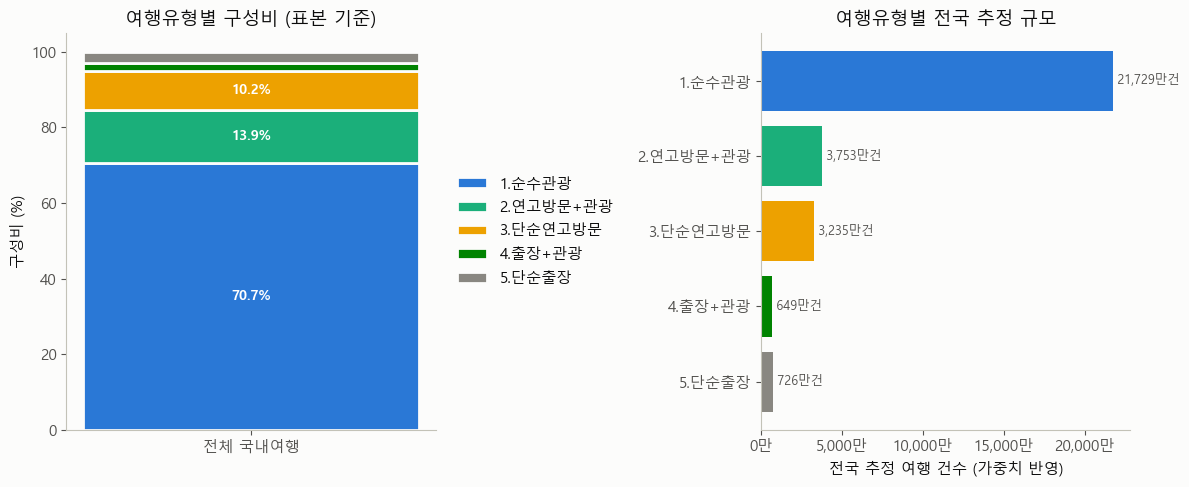

연고 방문(유형2+3)이 전체 국내여행에서 차지하는 전국 추정 비중: 23.3%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) 표본 기준 구성비 — 누적 막대
order = [1, 2, 3, 4, 5]
bottom = 0
for c in order:
    v = type_counts.loc[CASE_LABELS[c], '표본비중(%)']
    axes[0].bar(['전체 국내여행'], [v], bottom=bottom, color=CASE_COLORS[c], label=CASE_LABELS[c],
                edgecolor='#fcfcfb', linewidth=2)
    if v > 3:
        axes[0].text(0, bottom + v / 2, f'{v:.1f}%', ha='center', va='center', color='white', fontsize=10, fontweight='bold')
    bottom += v
axes[0].set_ylabel('구성비 (%)')
axes[0].set_title('여행유형별 구성비 (표본 기준)')
axes[0].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

# (b) 가중 추정 건수 — 가로 막대, 유형3 강조
vals = [type_counts.loc[CASE_LABELS[c], '가중추정건수'] for c in order]
colors = [CASE_COLORS[c] for c in order]
bars = axes[1].barh([CASE_LABELS[c] for c in order][::-1], vals[::-1], color=colors[::-1])
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e4:,.0f}만'))
axes[1].set_xlabel('전국 추정 여행 건수 (가중치 반영)')
axes[1].set_title('여행유형별 전국 추정 규모')
for b, v in zip(bars, vals[::-1]):
    axes[1].text(v, b.get_y() + b.get_height() / 2, f' {v/1e4:,.0f}만건', va='center', fontsize=9, color='#52514e')

plt.tight_layout()
plt.show()

renco_share = type_counts.loc[[CASE_LABELS[2], CASE_LABELS[3]], '가중추정비중(%)'].sum()
print(f'연고 방문(유형2+3)이 전체 국내여행에서 차지하는 전국 추정 비중: {renco_share:.1f}%')

**기대했던 결과와 비교**: 유형 3(단순 연고방문)의 절대 규모가 유형 2보다 큰지, 그리고 연고 방문 합계가 무시할 수 없는 비중(정책 문서에서
"전체의 O%, 연간 O만 건" 식으로 인용 가능한 수준)인지를 위 숫자로 직접 확인한다.

## 4. 분석 2 — 전환의 여지가 있는가 (지출 격차 검증)

**원기획안 대비 수정**: `NA8` 대신 응답률 100%인 `ONE_COST`(1인지출비용, 여행 총경비를 인원수로 나눈 값)를 사용한다.
유형 3 → 2 전환 시 발생하는 1인당 소비 증가분을 정량화하고, 그 차이가 통계적으로 유의한지 검정한다(원기획안에는 유의성 검정이 없었음 — 추가).

In [10]:
spend = trips[trips['CASE'].isin([1, 2, 3, 4])].copy()
spend = spend[spend['ONE_COST'].between(0, spend['ONE_COST'].quantile(0.995))]  # 극단 이상치 상한 컷

spend_summary = spend.groupby('CASE').agg(
    평균_1인지출=('ONE_COST', 'mean'),
    중위_1인지출=('ONE_COST', 'median'),
    표본수=('ONE_COST', 'size'),
).rename(index=CASE_LABELS).round(0)
spend_summary

,평균_1인지출,중위_1인지출,표본수
CASE,,,
1.순수관광,135919.0,93100.0,20088
2.연고방문+관광,115238.0,88500.0,3964
3.단순연고방문,78897.0,50000.0,2898
4.출장+관광,143275.0,95000.0,659


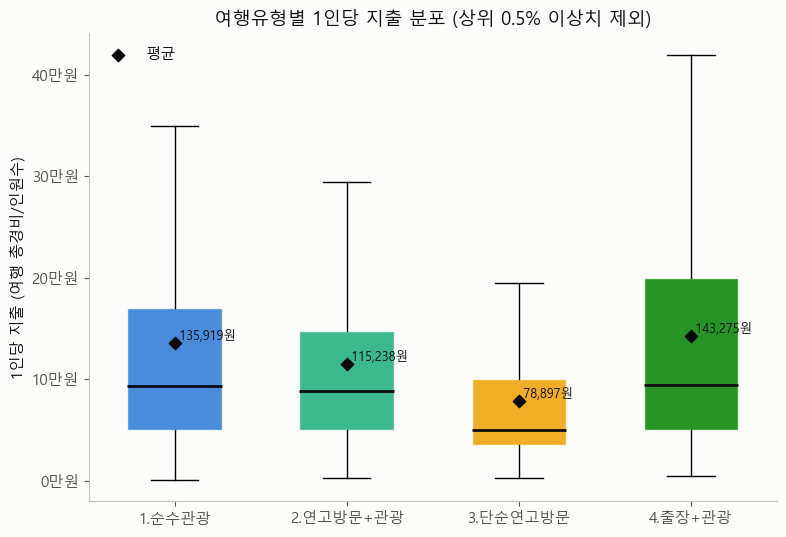

In [11]:
fig, ax = plt.subplots(figsize=(8, 5.5))
order = [1, 2, 3, 4]
data_by_case = [spend.loc[spend['CASE'] == c, 'ONE_COST'] for c in order]
bp = ax.boxplot(data_by_case, positions=range(len(order)), widths=0.55, patch_artist=True,
                 showfliers=False, medianprops=dict(color='#0b0b0b', linewidth=2))
for patch, c in zip(bp['boxes'], order):
    patch.set_facecolor(CASE_COLORS[c])
    patch.set_alpha(0.85)
    patch.set_edgecolor('#fcfcfb')

means = [spend.loc[spend['CASE'] == c, 'ONE_COST'].mean() for c in order]
ax.scatter(range(len(order)), means, color='#0b0b0b', zorder=5, marker='D', s=40, label='평균')
for i, m in enumerate(means):
    ax.text(i, m, f' {m:,.0f}원', va='bottom', fontsize=9)

ax.set_xticks(range(len(order)))
ax.set_xticklabels([CASE_LABELS[c] for c in order])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e4:,.0f}만원'))
ax.set_ylabel('1인당 지출 (여행 총경비/인원수)')
ax.set_title('여행유형별 1인당 지출 분포 (상위 0.5% 이상치 제외)')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [12]:
# ---- 유의성 검정: 유형3(단순방문) vs 유형2(관광포함 연고방문) ----
g2 = spend.loc[spend['CASE'] == 2, 'ONE_COST']
g3 = spend.loc[spend['CASE'] == 3, 'ONE_COST']
u_stat, p_val = stats.mannwhitneyu(g2, g3, alternative='greater')
gap = g2.mean() - g3.mean()
gap_pct = gap / g3.mean() * 100

print(f'유형2 평균: {g2.mean():,.0f}원 / 유형3 평균: {g3.mean():,.0f}원')
print(f'전환 시 1인당 지출 증가분: {gap:,.0f}원 (+{gap_pct:.0f}%)')
print(f'Mann-Whitney U 검정 (유형2 > 유형3): U={u_stat:,.0f}, p={p_val:.2e}')
print('※ 가중치(WT_DOM)는 표본 → 모집단 비중 추정에 쓰는 설계가중치라 순위검정에는 반영하지 않음. 대신 가중평균으로 교차검증:')
w_g2 = np.average(g2, weights=spend.loc[spend['CASE'] == 2, 'WT_DOM'])
w_g3 = np.average(g3, weights=spend.loc[spend['CASE'] == 3, 'WT_DOM'])
print(f'가중평균 — 유형2: {w_g2:,.0f}원 / 유형3: {w_g3:,.0f}원')

유형2 평균: 115,238원 / 유형3 평균: 78,897원
전환 시 1인당 지출 증가분: 36,341원 (+46%)
Mann-Whitney U 검정 (유형2 > 유형3): U=7,466,048, p=8.29e-101
※ 가중치(WT_DOM)는 표본 → 모집단 비중 추정에 쓰는 설계가중치라 순위검정에는 반영하지 않음. 대신 가중평균으로 교차검증:
가중평균 — 유형2: 112,110원 / 유형3: 71,794원


**참고(부표본 한정)**: A-series가 존재하는 일부 유형3 관측치(약 11%)에 한해 `NA8`의 항목별 세부내역(숙박·음식·활동·쇼핑)을 볼 수 있으나,
이는 대부분 응답자가 그 달에 **함께 다녀온 다른 유형의 여행** 지출일 가능성이 높아(1장 참조) 유형3 자체의 "항목별 소비 구성"으로 해석하지 않는다.
숙박 항목의 누수는 지출 총액이 아니라 **"숙박 장소 선택"** 자체로 다음 분석 3에서 확인한다.

## 5. 분석 3 — 소비는 왜 새어나가는가 (숙박 누수 진단 + 활동 프로필 비교)

**원기획안 대비 수정**: "활동 참여율(A4 결측 비율)"을 유형2 vs 3 비교 지표로 쓰는 부분은 제외한다. 유형3은 정의상 "관광/휴양 활동이
포함되지 않은" 여행이므로 활동 참여율이 0%에 가깝다는 것은 새로운 발견이 아니라 CASE 정의의 재확인(동어반복)이다.

대신 숙박 누수는 그대로 검증하고, **유형1(순수관광) vs 유형2(관광포함 연고방문)의 활동 프로필 차이**를 새로 비교한다(둘 다 A-series 응답률이
거의 100%라 편향 없이 비교 가능). 연고 방문객이 순수 관광객 대비 어떤 활동을 상대적으로 덜 하는지 알면, 정책 4장의 "체험 바우처"를
어떤 활동에 걸어야 할지 더 구체적인 근거가 된다(추가 분석).

In [13]:
# ---- (a) 숙박 누수: 유형별 당일/숙박 비율, 숙박 시 가족·친지집 비율 ----
leak = trips[trips['CASE'].isin([1, 2, 3])].copy()

overnight_rate = leak.groupby('CASE')['숙박여부'].apply(lambda s: (s == '숙박').mean())
among_overnight = leak[leak['숙박여부'] == '숙박']
family_house_rate = among_overnight.groupby('CASE')['가족친지집숙박'].mean()

leak_tbl = pd.DataFrame({
    '숙박여행 비율': overnight_rate,
    '숙박 시 가족·친지집 비율': family_house_rate,
}).rename(index=CASE_LABELS)
(leak_tbl * 100).round(1)

,숙박여행 비율,숙박 시 가족·친지집 비율
CASE,,
1.순수관광,28.5,3.7
2.연고방문+관광,53.4,85.7
3.단순연고방문,45.2,98.1


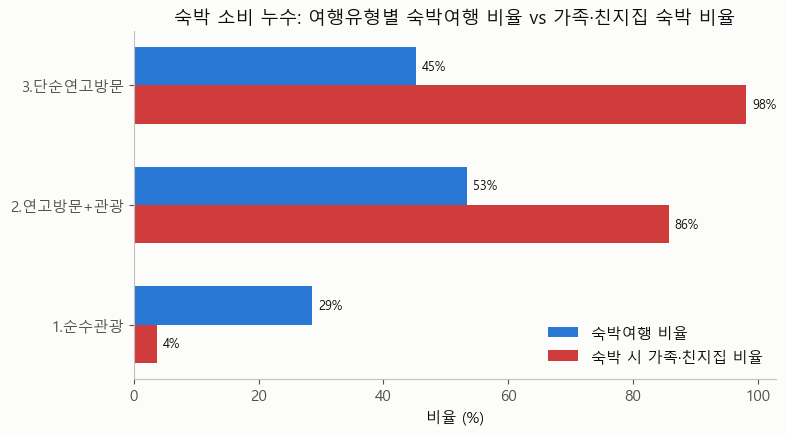

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.5))
order = [1, 2, 3]
y = np.arange(len(order))
h = 0.32
ax.barh(y + h/2, [overnight_rate[c] * 100 for c in order], height=h, color=CAT_COLORS[0], label='숙박여행 비율')
ax.barh(y - h/2, [family_house_rate.get(c, 0) * 100 for c in order], height=h, color=CRITICAL, label='숙박 시 가족·친지집 비율')
ax.set_yticks(y)
ax.set_yticklabels([CASE_LABELS[c] for c in order])
ax.set_xlabel('비율 (%)')
ax.set_title('숙박 소비 누수: 여행유형별 숙박여행 비율 vs 가족·친지집 숙박 비율')
ax.legend(frameon=False, loc='lower right')
for yi, c in zip(y, order):
    ax.text(overnight_rate[c] * 100 + 1, yi + h/2, f'{overnight_rate[c]*100:.0f}%', va='center', fontsize=9)
    v = family_house_rate.get(c, 0) * 100
    ax.text(v + 1, yi - h/2, f'{v:.0f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

**해석 포인트**: 유형3의 숙박여행 비율 자체가 낮다면 "애초에 하루 안에 돌아가는" 당일 연고방문이 많다는 뜻이고, 숙박여행 중에서도
가족·친지집 비율이 높다면 "숙박은 하되 지역 숙박업에는 돈이 남지 않는" 구조라는 뜻이다. 두 수치를 함께 봐야 바우처를 "숙박 유도형"으로
설계할지 "당일→숙박 전환형"으로 설계할지 판단할 수 있다.

In [15]:
# ---- (b) 활동 프로필: 유형1 vs 유형2 (A-series 응답 가능한 여행만) ----
A4_CODES = {
    1: '자연·풍경감상', 2: '음식관광', 3: '야외위락/스포츠', 4: '역사유적지', 5: '테마파크/놀이시설',
    6: '휴식/휴양', 7: '온천/스파', 8: '쇼핑', 9: '문화예술/공연', 10: '스포츠관람',
    11: '지역축제/이벤트', 12: '교육/체험프로그램', 13: '종교/성지순례', 14: '카지노/경마 등',
    15: '시티투어', 16: '공연장/촬영지', 17: '유흥/오락', 18: '가족·친지·친구방문', 19: '회의참가/시찰',
    20: '교육/훈련/연수', 21: '기타',
}
a4_cols = [f'A4_{i}' for i in A4_CODES]
main_trip_cols = ['ID', 'D_TRA1_CASE'] + a4_cols
a4_raw, _ = pyreadstat.read_sav(DATA_PATH, usecols=main_trip_cols)

a4 = a4_raw[a4_raw['D_TRA1_CASE'].isin([1, 2])].copy()
rate1 = a4.loc[a4['D_TRA1_CASE'] == 1, a4_cols].notna().mean()
rate2 = a4.loc[a4['D_TRA1_CASE'] == 2, a4_cols].notna().mean()

activity_cmp = pd.DataFrame({'순수관광(1)': rate1.values, '연고방문+관광(2)': rate2.values},
                             index=[A4_CODES[i] for i in A4_CODES]) * 100
activity_cmp['격차(2-1)p'] = activity_cmp['연고방문+관광(2)'] - activity_cmp['순수관광(1)']
activity_cmp = activity_cmp.sort_values('격차(2-1)p')
activity_cmp.round(1)

,순수관광(1),연고방문+관광(2),격차(2-1)p
자연·풍경감상,80.4,68.6,-11.8
음식관광,67.5,57.1,-10.4
야외위락/스포츠,8.1,3.5,-4.6
휴식/휴양,56.5,52.4,-4.1
테마파크/놀이시설,9.4,7.1,-2.3
역사유적지,11.3,9.9,-1.4
종교/성지순례,3.6,2.5,-1.1
쇼핑,7.6,6.6,-1.0
지역축제/이벤트,3.7,2.8,-0.9
시티투어,5.7,4.9,-0.9


## 6. 분석 4 — 어느 지역이 타겟인가 (지역 선정, 핵심 산출물)

시군구별로 두 지표를 계산해 사분면에 배치한다.

- **X축 — 연고 의존도**: 해당 지역 방문 여행 중 연고 방문(유형2+3)이 차지하는 비율(가중치 반영)
- **Y축 — 전환율**: 해당 지역 연고 방문 중 관광활동을 포함한 비율 = 유형2 / (유형2+유형3) (가중치 반영)

**원기획안 대비 추가한 안전장치**: 표본이 극히 적은 시군구는 비율이 우연히 0%나 100%에 가깝게 나와 사분면 끝에 찍히기 쉽다. 이런 지역이
"최우선 타겟"으로 잘못 뽑히지 않도록 **최소 표본 수 기준(가중치 미반영 원표본 20건)** 을 두고, 기준 미달 지역은 속이 빈 마커로 구분한다.

In [16]:
MIN_N = 20

def wavg(s, w):
    return np.average(s, weights=w) if w.sum() > 0 else np.nan

region = trips.dropna(subset=['SIDO_SHORT', 'SIGUNGU']).copy()
region['is_renco'] = region['CASE'].isin([2, 3])
region['is_case2'] = region['CASE'] == 2

grp = region.groupby(['SIDO_SHORT', 'SIGUNGU'])
reg_tbl = grp.apply(lambda g: pd.Series({
    '표본수': len(g),
    '가중표본수': g['WT_DOM'].sum(),
    '연고의존도': wavg(g['is_renco'].astype(float), g['WT_DOM']),
    '인구감소지역': g['인구감소지역'].iloc[0],
}), include_groups=False).reset_index()

renco_only = region[region['is_renco']]
grp2 = renco_only.groupby(['SIDO_SHORT', 'SIGUNGU'])
conv_tbl = grp2.apply(lambda g: pd.Series({
    '연고표본수': len(g),
    '전환율': wavg(g['is_case2'].astype(float), g['WT_DOM']),
}), include_groups=False).reset_index()

reg_tbl = reg_tbl.merge(conv_tbl, on=['SIDO_SHORT', 'SIGUNGU'], how='left')
reg_tbl['충분표본'] = reg_tbl['표본수'] >= MIN_N
reg_tbl = reg_tbl.dropna(subset=['전환율'])
print(f'분석 대상 시군구 수: {len(reg_tbl)} (표본 {MIN_N}건 이상: {reg_tbl["충분표본"].sum()}곳)')
reg_tbl.sort_values('가중표본수', ascending=False).head(10)

분석 대상 시군구 수: 229 (표본 20건 이상: 215곳)


,SIDO_SHORT,SIGUNGU,표본수,가중표본수,연고의존도,인구감소지역,연고표본수,전환율,충분표본
68,경북,경주시,729,7.087792e+06,0.104065,False,75.0,0.834386,True
4,강원,속초시,506,6.348697e+06,0.065972,False,32.0,0.858173,True
0,강원,강릉시,522,6.261907e+06,0.105660,False,59.0,0.824397,True
18,경기,가평군,396,6.091540e+06,0.060377,True,22.0,0.594250,True
201,제주,서귀포시,532,5.932582e+06,0.069373,False,46.0,0.845680,True
36,경기,양평군,355,5.391820e+06,0.084139,False,28.0,0.606028,True
202,제주,제주시,516,5.309362e+06,0.039282,False,26.0,0.942969,True
89,경북,포항시,524,4.950658e+06,0.176637,False,101.0,0.762978,True
123,부산,해운대구,465,4.791665e+06,0.140811,False,81.0,0.848337,True
177,전남,여수시,597,4.788070e+06,0.113342,False,70.0,0.742010,True


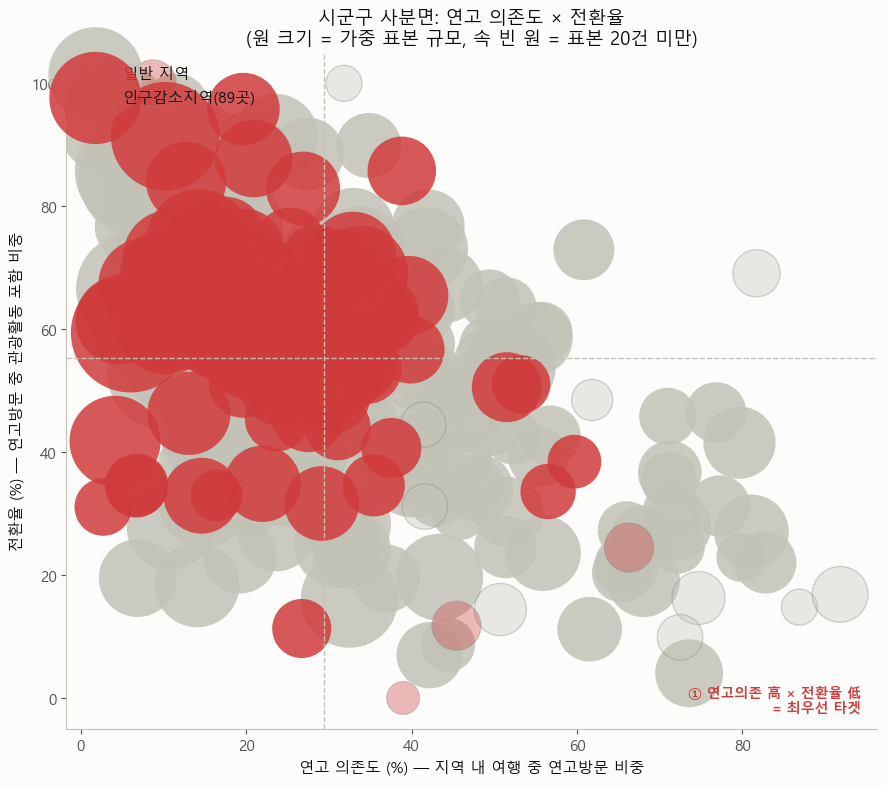

In [17]:
fig, ax = plt.subplots(figsize=(9, 8))

x_med, y_med = reg_tbl['연고의존도'].median(), reg_tbl['전환율'].median()

for is_decline, color, label in [(False, BASELINE, '일반 지역'), (True, CRITICAL, '인구감소지역(89곳)')]:
    sub = reg_tbl[reg_tbl['인구감소지역'] == is_decline]
    for enough, alpha, edge in [(True, 0.85, 'none'), (False, 0.35, '#898781')]:
        s2 = sub[sub['충분표본'] == enough]
        ax.scatter(s2['연고의존도'] * 100, s2['전환율'] * 100,
                    s=np.sqrt(s2['가중표본수']) * 3, color=color, alpha=alpha,
                    edgecolors=edge, linewidths=1,
                    label=label if enough else None)

ax.axvline(x_med * 100, color='#c3c2b7', linestyle='--', linewidth=1)
ax.axhline(y_med * 100, color='#c3c2b7', linestyle='--', linewidth=1)
ax.set_xlabel('연고 의존도 (%) — 지역 내 여행 중 연고방문 비중')
ax.set_ylabel('전환율 (%) — 연고방문 중 관광활동 포함 비중')
ax.set_title('시군구 사분면: 연고 의존도 × 전환율\n(원 크기 = 가중 표본 규모, 속 빈 원 = 표본 20건 미만)')
ax.legend(frameon=False, loc='upper left')

ax.text(0.98, 0.02, '① 연고의존 高 × 전환율 低\n= 최우선 타겟', transform=ax.transAxes,
        ha='right', va='bottom', fontsize=10, color=CRITICAL, fontweight='bold')

plt.tight_layout()
plt.show()

In [18]:
# ---- 최우선 타겟(1사분면) 목록: 연고의존도 高 & 전환율 低, 표본 충분, 인구감소지역 우선 ----
target = reg_tbl[(reg_tbl['연고의존도'] >= x_med) & (reg_tbl['전환율'] <= y_med) & (reg_tbl['충분표본'])].copy()
target = target.sort_values(['인구감소지역', '가중표본수'], ascending=[False, False])
target['지역'] = target['SIDO_SHORT'] + ' ' + target['SIGUNGU']
target_display = target[['지역', '인구감소지역', '표본수', '연고의존도', '전환율']].copy()
target_display['연고의존도'] = (target_display['연고의존도'] * 100).round(1)
target_display['전환율'] = (target_display['전환율'] * 100).round(1)
target_display.head(15).reset_index(drop=True)

,지역,인구감소지역,표본수,연고의존도,전환율
0,충북 보은군,True,131,32.1,53.1
1,경북 문경시,True,116,30.2,49.5
2,경남 함양군,True,68,34.6,53.6
3,경북 상주시,True,65,51.5,50.6
4,전북 임실군,True,57,34.1,53.7
5,충남 청양군,True,57,31.1,44.0
6,경북 고령군,True,42,35.4,34.6
7,전남 영암군,True,63,37.6,40.7
8,경북 의성군,True,33,53.3,51.0
9,부산 동구,True,25,56.5,33.6


> 이 목록의 상위 지역이 "정책 우선 적용 시군구" 후보다. 실제 정책 적용 시에는 표본 수가 여전히 통계청 공표 기준을 만족하는지,
> 최신(2026년 재지정 예정) 인구감소지역 고시와 일치하는지 재확인이 필요하다.

## 7. 분석 5 (추가) — 연고 방문의 계절성: 명절 집중도

기획안 1.3절은 "명절 귀성, 성묘, 벌초" 등을 연고 방문의 핵심 서사로 제시하지만, 정작 2장 EDA 설계에는 계절성 분석이 없다.
바우처를 "상시 운영"할지 "명절 등 특정 시기에 집중 운영"할지는 정책 설계에서 중요한 실무 결정이므로, 여행 시작월(`SMONTH`) 기준으로
유형별 월별 분포를 확인한다. 2025년 기준 설·추석은 각각 1~2월, 9~10월경에 위치한다.

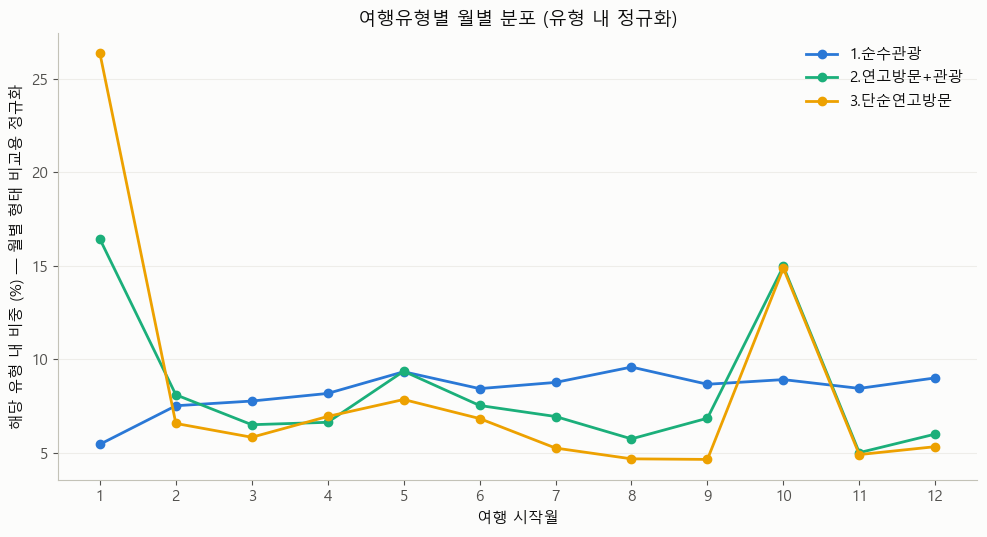

In [19]:
season = trips[trips['CASE'].isin([1, 2, 3])].copy()
season = season.dropna(subset=['SMONTH'])
season['SMONTH'] = season['SMONTH'].astype(int)

monthly = season.groupby(['SMONTH', 'CASE'])['WT_DOM'].sum().unstack('CASE').fillna(0)
monthly_share = monthly.div(monthly.sum(axis=0), axis=1) * 100  # 유형별로 월 분포를 정규화(유형간 규모차 제거, 형태 비교)

fig, ax = plt.subplots(figsize=(10, 5.5))
for c in [1, 2, 3]:
    ax.plot(monthly_share.index, monthly_share[c], marker='o', color=CASE_COLORS[c], label=CASE_LABELS[c], linewidth=2)
ax.set_xticks(range(1, 13))
ax.set_xlabel('여행 시작월')
ax.set_ylabel('해당 유형 내 비중 (%) — 월별 형태 비교용 정규화')
ax.set_title('여행유형별 월별 분포 (유형 내 정규화)')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

**해석 포인트**: 유형2·3(연고방문)의 곡선이 유형1(순수관광)보다 특정 월(설·추석이 낀 달)에 더 뾰족하게 솟아 있다면, 이는 연고 방문이
순수관광 대비 훨씬 계절 집중적이라는 뜻이다. 이 경우 바우처 예산을 연중 균등 배분하기보다 명절 성수기에 집중 투입하는 편이 효율적이다.

## 8. 분석 6 (추가, 부표본 한정) — 동반자 구성이 전환과 함께 가는가

정책 4장 "3단계 동반 증폭 인센티브"는 "친구 등 외지 동반자를 데려오면 전환 확률이 높아진다"는 가설에 기반한다. 이를 로지스틱 회귀(9장) 전에
먼저 기술통계로 확인한다. 다만 **동반인원수(`D_TRA*_NUM`, 전체표본)** 와 **동반자 유형(`A6B_*`, A-series 부표본)** 은 데이터 가용성이
다르므로 나눠서 본다.

In [20]:
# ---- (a) 동반인원수: 전체표본, 편향 없음 ----
num_cmp = trips[trips['CASE'].isin([2, 3])].groupby('CASE')['NUM'].agg(['mean', 'median', 'size'])
num_cmp.index = num_cmp.index.map(CASE_LABELS)
print('동반인원수(D_TRA*_NUM) — 전체표본:')
display(num_cmp.round(2))

u_stat, p_val = stats.mannwhitneyu(
    trips.loc[trips['CASE'] == 2, 'NUM'].dropna(),
    trips.loc[trips['CASE'] == 3, 'NUM'].dropna(), alternative='two-sided')
print(f'Mann-Whitney U 검정 p={p_val:.2e}')

동반인원수(D_TRA*_NUM) — 전체표본:


,mean,median,size
CASE,,,
2.연고방문+관광,2.46,2.0,3977
3.단순연고방문,2.13,2.0,2902


Mann-Whitney U 검정 p=1.95e-25


In [21]:
# ---- (b) 친구동반 여부(A6B_7): A-series 부표본 한정, 참고용 ----
companion_cols = ['ID', 'D_TRA1_CASE', 'A6', 'A6B_7']
comp_raw, _ = pyreadstat.read_sav(DATA_PATH, usecols=companion_cols)
comp = comp_raw[comp_raw['D_TRA1_CASE'].isin([2, 3])].copy()
comp_valid = comp[comp['A6'].notna()]  # A-series 응답이 존재하는 행만(위 1장 caveat)

friend_rate = comp_valid.groupby('D_TRA1_CASE')['A6B_7'].apply(lambda s: s.notna().mean())
print('※ 부표본 크기(유형3은 특히 작아 해석에 주의):')
print(comp_valid['D_TRA1_CASE'].value_counts())
print()
print('친구동반 비율 (A-series 응답 존재 부표본 한정):')
print((friend_rate * 100).round(1).rename(index=CASE_LABELS))

※ 부표본 크기(유형3은 특히 작아 해석에 주의):
D_TRA1_CASE
2.0    3844
3.0     277
Name: count, dtype: int64

친구동반 비율 (A-series 응답 존재 부표본 한정):
D_TRA1_CASE
2.연고방문+관광    11.0
3.단순연고방문     24.2
Name: A6B_7, dtype: float64


**해석 포인트**: (a)는 전체표본 기준으로 신뢰할 수 있는 결과이므로 정책 문서에 바로 인용 가능하다. (b)는 표본이 작고 "A-series가 존재하는
사람"이라는 조건 자체가 이미 활동적인 방문객 쪽으로 치우쳐 있을 수 있어(선택 편향), 방향성 참고 이상의 근거로 쓰지 않는다.

## 9. 분석 7 (추가) — 유형3은 왜 관광을 추가하지 않는가: 장벽 진단 (ZQ1)

8장까지의 분석은 전환 여부와 함께 움직이는 여행의 "구조적 조건"(동반인원수, 숙박여부, 계절성 등)만 다뤘다. 하지만 정책이 실제로 설계하려는 것은 인센티브이므로,
응답자가 **왜** 관광·휴양 활동을 하지 않았는지 직접 물은 문항이 있는지부터 확인해야 한다.

국민여행조사에는 `ZQ1_1~3`("이번 (#)월에 관광·휴양여행을 한 번도 가지 않으신 이유는 무엇입니까?", 1~3순위, 12개 보기)이라는 문항이 있다.
이 문항은 그 달에 관광을 포함한 여행을 전혀 하지 않은 응답자에게만 노출되므로, 유형3(단순연고방문)·유형5(단순출장) 응답자의 88.1%/84.3%가 답했다 —
A-series와는 반대로 **정확히 이 정책이 전환시키려는 인구집단에게 노출되는 문항**이다.

**주의**: 1장·8장에서 확인한 것과 같은 함정이 여기도 있다. 그 달에 유형1/2/4(관광 포함) 여행을 별도로 다녀온 응답자는 "관광을 한 번도 안 갔다"가
아니므로 ZQ1이 애초에 공란이거나, 반대로 응답이 섞여도 유형3/5 트립 자체의 장벽을 대표하지 않는다. 따라서 아래 집계는 **그 달에 다른 차수 여행이
유형1/2/4로 잡히지 않은 응답자만**으로 정제한 표본에서 수행한다(위 `trips` 데이터프레임으로 판정).

In [22]:
# ---- ZQ1: 관광을 한 번도 안 간 이유 (유형3/5, 오염 없는 부표본) ----
zq1_cols = ['ID', 'D_TRA1_CASE', 'ZQ1_1', 'ZQ1_2', 'ZQ1_3']
zq1_raw, meta_zq1 = pyreadstat.read_sav(DATA_PATH, usecols=zq1_cols)
zq1_labels = meta_zq1.variable_value_labels.get('ZQ1_1', {})

ids_with_tourism_trip = set(trips.loc[trips['CASE'].isin([1, 2, 4]), 'ID'])

zq1_35_raw = zq1_raw[zq1_raw['D_TRA1_CASE'].isin([3, 5])]
zq1_clean = zq1_35_raw[~zq1_35_raw['ID'].isin(ids_with_tourism_trip)].copy()

print(f'유형3/5 원표본: {len(zq1_35_raw)}건 -> 같은 달 관광포함 여행(1/2/4)도 있었던 응답자 제외 후: {len(zq1_clean)}건')
print(zq1_clean['D_TRA1_CASE'].value_counts().rename(index=CASE_LABELS))
print()
print('ZQ1 응답률(정제 표본 기준):')
print((zq1_clean.groupby('D_TRA1_CASE')['ZQ1_1'].apply(lambda s: s.notna().mean()) * 100).round(1).rename(index=CASE_LABELS))

유형3/5 원표본: 3193건 -> 같은 달 관광포함 여행(1/2/4)도 있었던 응답자 제외 후: 2811건
D_TRA1_CASE
3.단순연고방문    2226
5.단순출장       585
Name: count, dtype: int64

ZQ1 응답률(정제 표본 기준):
D_TRA1_CASE
3.단순연고방문    99.0
5.단순출장      99.5
Name: ZQ1_1, dtype: float64


In [23]:
# ---- 1순위 이유 분포: 유형3 vs 유형5 ----
reason_3 = (zq1_clean.loc[zq1_clean['D_TRA1_CASE'] == 3, 'ZQ1_1']
            .map(zq1_labels).value_counts(normalize=True).mul(100).round(1))
reason_5 = (zq1_clean.loc[zq1_clean['D_TRA1_CASE'] == 5, 'ZQ1_1']
            .map(zq1_labels).value_counts(normalize=True).mul(100).round(1))

reason_cmp = pd.DataFrame({
    '유형3(단순연고방문) 1순위 이유 %': reason_3,
    '유형5(단순출장) 1순위 이유 %': reason_5,
}).fillna(0.0).sort_values('유형3(단순연고방문) 1순위 이유 %', ascending=False)
reason_cmp

,유형3(단순연고방문) 1순위 이유 %,유형5(단순출장) 1순위 이유 %
ZQ1_1,,
시간이 없어서,39.9,52.1
"가족, 친구와 시간을 맞추기 힘들어서",19.6,14.1
최근에 여행을 다녀와서,12.0,7.9
여행에 관심이 없어서,7.1,6.2
여행 경비가 부족해서,5.7,2.2
함께 여행할 사람이 없어서,3.8,3.3
건강상의 문제로,3.2,6.4
여행이 재미없을 것 같아서,2.3,1.9
집안에 돌봐야 하는 가족이 있어서,2.0,1.7


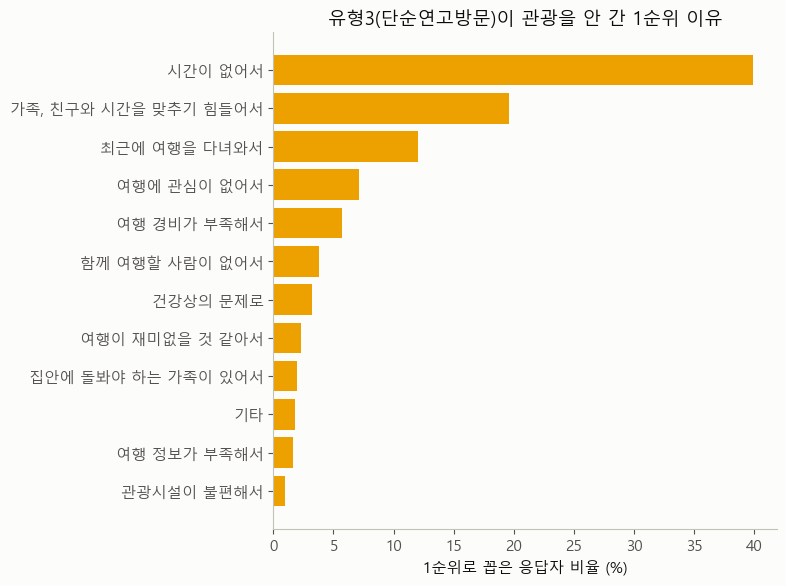

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))
order = reason_cmp.index[::-1]
y = np.arange(len(order))
ax.barh(y, reason_cmp.loc[order, '유형3(단순연고방문) 1순위 이유 %'], color=CASE_COLORS[3])
ax.set_yticks(y)
ax.set_yticklabels(order)
ax.set_xlabel('1순위로 꼽은 응답자 비율 (%)')
ax.set_title('유형3(단순연고방문)이 관광을 안 간 1순위 이유')
plt.tight_layout()
plt.show()

**해석 포인트**: 위 순위표에서 상위권 이유와 정책 4장의 3단계 바우처 설계를 직접 대응시킬 수 있다 —
"여행 경비가 부족해서"가 상위면 1단계(숙박 전환 바우처)·2단계(체험·식비 바우처)의 타겟이 정확하다는 근거가 되고,
"함께 여행할 사람이 없어서"의 비중이 낮다면 3단계(동반 증폭 인센티브)는 메인이 아니라 보조 장치로 두는 원기획안의 판단(4.1절)이 데이터로도
뒷받침된다. 반대로 "여행 정보가 부족해서"나 "관광시설이 불편해서"처럼 **바우처(돈)로는 직접 풀리지 않는 이유**가 상위에 있다면,
정보 제공(10장에서 확인하는 채널)이나 시설 개선처럼 예산 외 레버가 함께 필요하다는 뜻이다.

## 10. 분석 8 (추가) — 전환에 성공한 사람들은 정보를 어디서 얻는가 (A5/A5A)

활동 프로필(유형1 vs 2) 비교는 이미 5장에서 다뤘다. 여기서는 지금까지 전혀 쓰이지 않은 **정보 획득 경로** 변수를 본다 —
`A5`(여행 정보를 주로 어디서 얻었는가: 인터넷/방송/광고/여행사/주변인/과거경험/정보없이방문 등)와, 인터넷 이용자에 한해 물은 `A5A`(어떤
인터넷 채널: 블로그/SNS/유튜브/챗GPT 등). 두 변수 모두 A-series라 유형3에는 없지만, 유형1·2는 응답률이 100%라 편향 없이 비교할 수 있다(5장과
동일한 논리).

기획안의 "고향 바우처 + **SNS 연계**" 모델이 실제로 전환에 성공한 사람들(유형2)의 정보 소비 행태와 맞는지 확인한다.

In [25]:
# ---- A5: 정보 획득 경로, 유형1 vs 유형2 (둘 다 응답률 100%) ----
info_cols = ['ID', 'D_TRA1_CASE', 'A5_1', 'A5A_1']
info_raw, meta_info = pyreadstat.read_sav(DATA_PATH, usecols=info_cols)
a5_labels = meta_info.variable_value_labels.get('A5_1', {})
a5a_labels = meta_info.variable_value_labels.get('A5A_1', {})

info = info_raw[info_raw['D_TRA1_CASE'].isin([1, 2])].copy()
print('A5 응답률:', (info.groupby('D_TRA1_CASE')['A5_1'].apply(lambda s: s.notna().mean()) * 100).round(1).rename(index=CASE_LABELS).to_dict())

channel_1 = info.loc[info['D_TRA1_CASE'] == 1, 'A5_1'].map(a5_labels).value_counts(normalize=True).mul(100).round(1)
channel_2 = info.loc[info['D_TRA1_CASE'] == 2, 'A5_1'].map(a5_labels).value_counts(normalize=True).mul(100).round(1)

channel_cmp = pd.DataFrame({'순수관광(1) %': channel_1, '연고방문+관광(2) %': channel_2}).fillna(0.0)
channel_cmp['격차(2-1)p'] = channel_cmp['연고방문+관광(2) %'] - channel_cmp['순수관광(1) %']
channel_cmp = channel_cmp.sort_values('연고방문+관광(2) %', ascending=False)
channel_cmp

A5 응답률: {'1.순수관광': 100.0, '2.연고방문+관광': 100.0}


,순수관광(1) %,연고방문+관광(2) %,격차(2-1)p
A5_1,,,
과거 방문 경험,36.7,48.3,11.6
주변인(친지/친구/동료 등),28.1,23.4,-4.7
정보 없이 방문,11.0,19.5,8.5
인터넷 사이트/모바일 앱(PC/스마트폰),17.1,5.5,-11.6
광고(TV/라디오/신문/잡지/지하철/옥외광고판 등),2.5,1.2,-1.3
기사 및 방송 프로그램(TV/라디오/신문/잡지),2.7,1.1,-1.6
관광 안내 서적,0.7,0.4,-0.3
"여행사(방문, 전화)",1.0,0.4,-0.6
기타,0.0,0.0,0.0


In [26]:
# ---- A5A: 인터넷 이용자 중 세부 채널, 유형1 vs 유형2 ----
net_users = info[info['A5_1'] == 1]

net_1 = net_users.loc[net_users['D_TRA1_CASE'] == 1, 'A5A_1'].map(a5a_labels).value_counts(normalize=True).mul(100).round(1)
net_2 = net_users.loc[net_users['D_TRA1_CASE'] == 2, 'A5A_1'].map(a5a_labels).value_counts(normalize=True).mul(100).round(1)

net_channel_cmp = pd.DataFrame({'순수관광(1) %': net_1, '연고방문+관광(2) %': net_2}).fillna(0.0)
net_channel_cmp = net_channel_cmp.sort_values('연고방문+관광(2) %', ascending=False)
net_channel_cmp

,순수관광(1) %,연고방문+관광(2) %
A5A_1,,
"인터넷/웹사이트 커뮤니티 게시판 (네이버 블로그, 다음 카페 등)",50.2,49.8
동영상 사이트(유튜브 등),12.3,13.3
"SNS(인스타그램, 페이스북 등)",13.4,12.3
인터넷/웹사이트 지도/평가 정보,10.2,10.0
인터넷/웹사이트 여행 관련 (신문)기사/컬럼,4.7,7.1
여행 및 숙박 전문 사이트 또는 앱,5.3,3.3
"대화형 인공지능서비스(챗GPT, 뤼튼 등)",1.2,2.4
공공기관 홈페이지,1.2,1.4
개별 관광지 또는 관광시설 홈페이지,0.7,0.5


**해석 포인트**: `channel_cmp`에서 유형2가 유형1보다 "주변인(친지/친구/동료)"이나 "과거 방문 경험" 비중이 높게 나온다면, 연고 방문객은
매번 새로 검색하기보다 이미 아는 경로로 관광을 결정한다는 뜻이므로 SNS 광고보다 **재방문 유도형 콘텐츠**(예: 이전 방문자 후기, 반복 방문
혜택)가 더 유효할 수 있다. 반대로 인터넷/SNS 비중이 유형1과 비슷하거나 더 높다면 기획안의 SNS 연계 가설이 지지된다. `net_channel_cmp`는
그 인터넷 채널 중 어디(블로그/SNS/유튜브/공공기관 홈페이지 등)에 집중해야 하는지까지 좁혀준다.

## 11. 로지스틱 회귀 — 무엇이 전환을 만드는가

**종속변수**: 전환 여부. 유형2=1(전환), 유형3=0(미전환).

9장(ZQ1 장벽 진단)·10장(A5 정보채널)에서 확인한 요인들은 아래 독립변수와 다음과 같이 대응된다 — 여행일수(`S_Day`)↔"시간이 없어서", 동반인원수(`NUM`)↔"함께 여행할 사람이 없어서", 숙박 여부↔"여행 경비가 부족해서", 계절성(month_sin/cos)↔명절 시기 집중, 가구원수(`BFAM`)↔"집안에 돌봐야 하는 가족이 있어서". 즉 아래 독립변수는 임의로 고른 통제변수가 아니라, 9장에서 응답자가 직접 꼽은 장벽을 정량화할 수 있는 대리변수(proxy)로 고른 것이다 — 이 절이 존재하는 이유는 "무엇이 전환과 상관관계가 있는가"가 아니라 "9장의 장벽 중 어떤 것이 실제로 전환 여부를 가르는 데 유의미한가"를 확인해 정책 레버의 우선순위를 정하기 위함이다.

**원기획안 대비 수정한 독립변수 구성**: A-series 결측 문제(1장) 때문에 `A6B_7`(친구동반) 등은 주모형에서 제외하고,
전체표본에서 편향 없이 쓸 수 있는 여행 차수별 종합정보 변수와 응답자 인구통계로 주모형을 구성한다. 목적지가 인구감소지역인지 여부도
독립변수로 추가한다(원기획안에는 없던 항목 — 소멸위기 지역 자체의 특성이 전환을 어렵게 만드는지 확인).

- 여행일수(`S_Day`), 동반인원수(`NUM`), 숙박여부(당일/숙박)
- 계절성: 월을 sin/cos로 변환한 순환 변수(단순 더미보다 "명절 시기"처럼 순환적인 계절 효과를 매끄럽게 반영)
- 목적지가 인구감소지역인지 여부
- 응답자 특성: 연령대(`BAGE`), 성별(`BSEX`), 차량보유(`DQ7`), 가구원수(`BFAM`)

**한 응답자가 여러 여행(행)을 제공**하므로 관측치 간 독립성이 깨진다 — 응답자 ID로 군집 표준오차를 적용한다(원기획안에는 없던 보정, 추가).

In [27]:
model_df = trips[trips['CASE'].isin([2, 3])].copy()
model_df['Y'] = (model_df['CASE'] == 2).astype(int)
model_df['숙박'] = (model_df['숙박여부'] == '숙박').astype(int)
model_df['month_sin'] = np.sin(2 * np.pi * model_df['SMONTH'] / 12)
model_df['month_cos'] = np.cos(2 * np.pi * model_df['SMONTH'] / 12)
model_df['인구감소지역_num'] = model_df['인구감소지역'].astype(int)
model_df['DQ7_num'] = (model_df['DQ7'] == '보유').astype(int)
model_df['BSEX_num'] = (model_df['BSEX'] == '남').astype(int)

model_df = model_df.dropna(subset=['S_Day', 'NUM', '숙박', 'BAGE', 'BFAM', 'DQ7_num', 'BSEX_num'])
print('모형 표본수:', len(model_df), '/ 응답자 수:', model_df['ID'].nunique())
model_df[['Y', 'S_Day', 'NUM', '숙박', '인구감소지역_num', 'BAGE', 'BFAM']].describe()

모형 표본수: 6879 / 응답자 수: 6630


,Y,S_Day,NUM,숙박,인구감소지역_num,BAGE,BFAM
count,6879.000000,6879.000000,6879.000000,6879.000000,6879.000000,6879.000000,6879.000000
mean,0.578136,0.811891,2.320395,0.499491,0.318215,4.415031,2.203518
std,0.493893,1.168215,1.276641,0.500036,0.465817,1.606457,0.801739
min,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000
25%,0.000000,0.000000,1.000000,0.000000,0.000000,3.000000,2.000000
50%,1.000000,1.000000,2.000000,0.000000,0.000000,4.000000,2.000000
75%,1.000000,1.000000,3.000000,1.000000,1.000000,6.000000,3.000000
max,1.000000,25.000000,20.000000,1.000000,1.000000,7.000000,3.000000


In [28]:
# ---- 다중공선성(VIF) 점검 ----
X_vif = model_df[['S_Day', 'NUM', '숙박', 'month_sin', 'month_cos', '인구감소지역_num',
                   'BAGE', 'BSEX_num', 'DQ7_num', 'BFAM']].astype(float)
X_vif_c = sm.add_constant(X_vif)
vif = pd.Series(
    [variance_inflation_factor(X_vif_c.values, i) for i in range(X_vif_c.shape[1])],
    index=X_vif_c.columns,
)
vif.drop('const')

S_Day         1.596121
NUM           1.157006
숙박            1.584030
month_sin     1.004997
month_cos     1.027564
인구감소지역_num    1.020026
BAGE          1.072527
BSEX_num      1.019887
DQ7_num       1.215239
BFAM          1.345562
dtype: float64

VIF가 모두 10 미만이면 다중공선성 문제가 없다고 보고 전체 변수를 유지한다. 이후 후진 단계적 선택(backward stepwise, 유의수준 0.05 기준)으로
불필요한 변수를 정리한다.

In [29]:
def backward_stepwise(df, y_col, x_cols, cluster_col, alpha=0.05):
    cols = list(x_cols)
    while True:
        formula = f"{y_col} ~ " + " + ".join(cols)
        fit = smf.logit(formula, data=df).fit(disp=0,
                cov_type='cluster', cov_kwds={'groups': df[cluster_col]})
        pvals = fit.pvalues.drop('Intercept')
        worst = pvals.idxmax()
        if pvals[worst] > alpha and len(cols) > 1:
            cols.remove(worst)
        else:
            return fit, cols

x_cols = ['S_Day', 'NUM', '숙박', 'month_sin', 'month_cos', '인구감소지역_num',
          'BAGE', 'BSEX_num', 'DQ7_num', 'BFAM']
final_model, final_cols = backward_stepwise(model_df, 'Y', x_cols, 'ID')
print('최종 선택 변수:', final_cols)
final_model.summary()

최종 선택 변수: ['S_Day', 'NUM', '숙박', 'month_sin', 'month_cos', '인구감소지역_num', 'BFAM']


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      Y   No. Observations:                 6879
Model:                          Logit   Df Residuals:                     6871
Method:                           MLE   Df Model:                            7
Date:                Sun, 05 Jul 2026   Pseudo R-squ.:                 0.03412
Time:                        21:59:09   Log-Likelihood:                -4524.0
converged:                       True   LL-Null:                       -4683.8
Covariance Type:              cluster   LLR p-value:                 3.806e-65
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0734      0.085     -0.867      0.386      -0.239       0.093
S_Day          0.1104      0.046      2.385      0.017       0.020       0.201
NUM            0.2692      0.024     11.161      0.000       0.222       0.316
숙박             0.2055      0.079      2.585      0.010       0.050       0.361
month_sin     -0.1214      0.037     -3.280      0.001      -0.194      -0.049
month_cos     -0.2596      0.037     -7.086      0.000      -0.331      -0.188
인구감소지역_num     0.2911      0.055      5.254      0.000       0.182       0.400
BFAM          -0.2107      0.034     -6.134      0.000      -0.278      -0.143
==============================================================================
"""

In [30]:
# ---- 오즈비 해석표 ----
or_tbl = pd.DataFrame({
    '계수': final_model.params,
    '오즈비': np.exp(final_model.params),
    'p-value': final_model.pvalues,
    '95%CI_low': np.exp(final_model.conf_int()[0]),
    '95%CI_high': np.exp(final_model.conf_int()[1]),
}).drop('Intercept')
or_tbl.round(3)

,계수,오즈비,p-value,95%CI_low,95%CI_high
S_Day,0.110,1.117,0.017,1.020,1.223
NUM,0.269,1.309,0.000,1.248,1.372
숙박,0.205,1.228,0.010,1.051,1.435
month_sin,-0.121,0.886,0.001,0.824,0.952
month_cos,-0.260,0.771,0.000,0.718,0.829
인구감소지역_num,0.291,1.338,0.000,1.200,1.491
BFAM,-0.211,0.810,0.000,0.757,0.866


오즈비가 1보다 크면 해당 변수가 증가(또는 해당 조건 충족)할 때 "관광활동을 포함한 연고 방문(전환)"일 오즈가 커진다는 뜻이다.
예: `숙박` 오즈비가 2.0이라면 "당일치기 대신 숙박을 하면 전환 오즈가 약 2배"라는 정책 언어로 옮길 수 있다 — 4장 "1단계 숙박 전환 바우처"의
직접 근거다.

In [31]:
# ---- 모형 적합도: McFadden 의사 R^2, AUC, 혼동행렬 (원기획안에는 없던 진단, 추가) ----
null_formula = "Y ~ 1"
null_model = smf.logit(null_formula, data=model_df).fit(disp=0)
mcfadden_r2 = 1 - final_model.llf / null_model.llf
pred_prob = final_model.predict(model_df)
auc = roc_auc_score(model_df['Y'], pred_prob)
pred_class = (pred_prob >= 0.5).astype(int)
cm = confusion_matrix(model_df['Y'], pred_class)

print(f'McFadden 의사 R^2: {mcfadden_r2:.3f}')
print(f'AUC: {auc:.3f}')
print('혼동행렬 [실제0/1 x 예측0/1]:')
print(cm)

McFadden 의사 R^2: 0.034
AUC: 0.624
혼동행렬 [실제0/1 x 예측0/1]:
[[ 823 2079]
 [ 686 3291]]


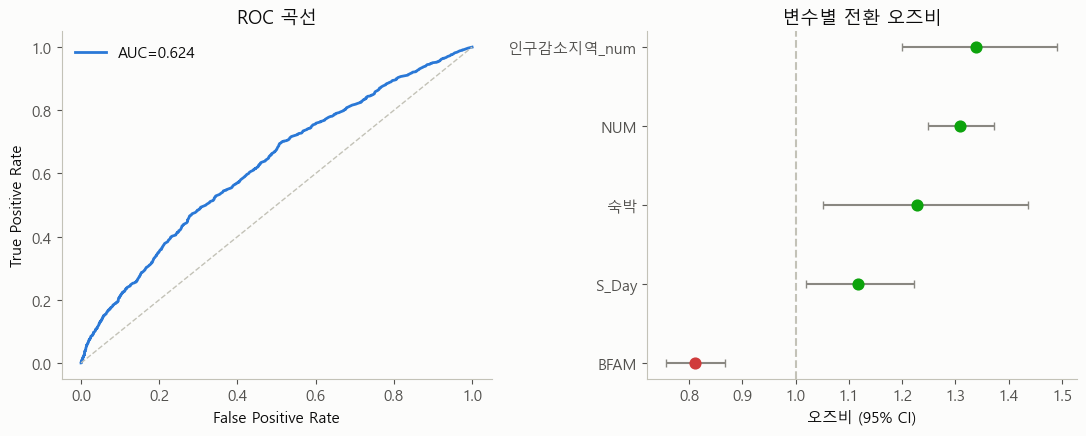

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

fpr, tpr, _ = roc_curve(model_df['Y'], pred_prob)
axes[0].plot(fpr, tpr, color=CAT_COLORS[0], linewidth=2, label=f'AUC={auc:.3f}')
axes[0].plot([0, 1], [0, 1], color='#c3c2b7', linestyle='--', linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC 곡선')
axes[0].legend(frameon=False)

or_plot = or_tbl.drop(index=[c for c in ['month_sin', 'month_cos'] if c in or_tbl.index]).sort_values('오즈비')
colors = [GOOD if v > 1 else CRITICAL for v in or_plot['오즈비']]
axes[1].errorbar(or_plot['오즈비'], range(len(or_plot)),
                  xerr=[or_plot['오즈비'] - or_plot['95%CI_low'], or_plot['95%CI_high'] - or_plot['오즈비']],
                  fmt='o', color='#0b0b0b', ecolor='#898781', capsize=3)
for i, v in enumerate(or_plot['오즈비']):
    axes[1].scatter([v], [i], color=colors[i], zorder=5, s=60)
axes[1].axvline(1, color='#c3c2b7', linestyle='--')
axes[1].set_yticks(range(len(or_plot)))
axes[1].set_yticklabels(or_plot.index)
axes[1].set_xlabel('오즈비 (95% CI)')
axes[1].set_title('변수별 전환 오즈비')

plt.tight_layout()
plt.show()

### 보조 진단 — 랜덤포레스트 변수중요도 (비선형 상호작용 확인용, 가벼운 보조지표)

기획안 3.3절이 언급한 대로, 로지스틱 회귀의 선형 가정을 벗어난 상호작용이 있는지 가볍게 확인하는 용도로만 사용한다.
튜닝 없이 변수 중요도 순위가 로지스틱 회귀의 유의 변수 순위와 대체로 일치하는지만 본다.

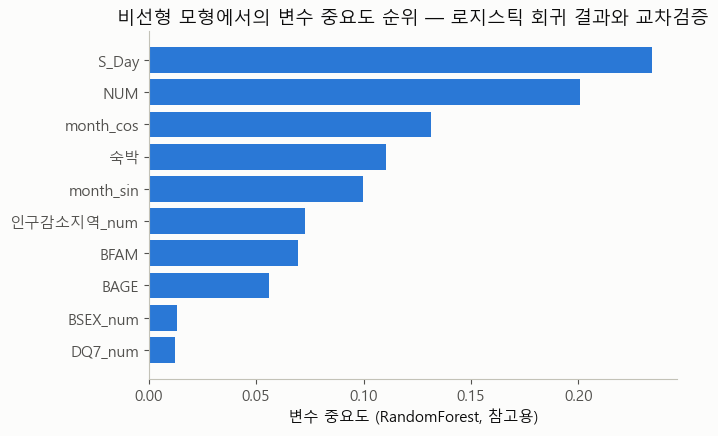

In [33]:
rf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, n_jobs=-1)
rf.fit(X_vif, model_df['Y'])
importance = pd.Series(rf.feature_importances_, index=X_vif.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(importance.index[::-1], importance.values[::-1], color=CAT_COLORS[0])
ax.set_xlabel('변수 중요도 (RandomForest, 참고용)')
ax.set_title('비선형 모형에서의 변수 중요도 순위 — 로지스틱 회귀 결과와 교차검증')
plt.tight_layout()
plt.show()

## 12. 전략 제언 — 장벽 × 정보채널 × 모델을 정책으로 연결

9~11장, 그리고 4장(지역 타겟)·7장(계절성)의 결과를 하나의 표로 모은다. 아래 수치는 각 장에서 이미 계산한 `reason_cmp`, `channel_cmp`, `or_tbl`
값을 그대로 인용한 것이다(재계산 아님).

In [34]:
# ---- 장벽 x 정보채널 x 모델 오즈비 종합 ----
top_reason_3 = reason_cmp['유형3(단순연고방문) 1순위 이유 %'].idxmax()
top_reason_pct = reason_cmp['유형3(단순연고방문) 1순위 이유 %'].max()

top_channel_2 = channel_cmp['연고방문+관광(2) %'].idxmax()
top_channel_pct = channel_cmp['연고방문+관광(2) %'].max()

strategy_tbl = pd.DataFrame([
    {'근거': '9장 ZQ1(장벽)', '핵심 수치': f'유형3 1순위 이유 1위: "{top_reason_3}" ({top_reason_pct:.1f}%)',
     '대응 정책 레버': '이 이유가 경비/체험형(바우처로 해결 가능)인지, 정보/시설형(별도 레버 필요)인지 구분해 예산 배분'},
    {'근거': '10장 A5(정보채널)', '핵심 수치': f'유형2 최다 정보채널: "{top_channel_2}" ({top_channel_pct:.1f}%)',
     '대응 정책 레버': '홍보 예산을 이 채널에 집중 배분'},
    {'근거': '11장 오즈비(숙박)', '핵심 수치': f'오즈비 {or_tbl.loc["숙박", "오즈비"]:.2f} (p={or_tbl.loc["숙박", "p-value"]:.3f})',
     '대응 정책 레버': '1단계 숙박 전환 바우처 — 오즈비로 효과 크기 근거 확보'},
    {'근거': '11장 오즈비(동반인원수 NUM)', '핵심 수치': f'오즈비 {or_tbl.loc["NUM", "오즈비"]:.2f}',
     '대응 정책 레버': '3단계 동반 증폭 인센티브의 기대 효과 크기'},
    {'근거': '11장 오즈비(가구원수 BFAM)', '핵심 수치': f'오즈비 {or_tbl.loc["BFAM", "오즈비"]:.2f} (1 미만 = 돌봄 부담이 전환을 억제)',
     '대응 정책 레버': '돌봄 부담 가구 대상 별도 지원(체류 중 돌봄 서비스 연계 등) 검토'},
    {'근거': '4장 지역 타겟', '핵심 수치': '연고의존도 高·전환율 低 사분면 시군구 목록', '대응 정책 레버': '1차 시범지역 선정'},
    {'근거': '7장 계절성', '핵심 수치': '연고 방문의 명절 집중도', '대응 정책 레버': '바우처 상시 운영 vs 명절 성수기 집중 운영 여부 결정'},
]).set_index('근거')
strategy_tbl

,핵심 수치,대응 정책 레버
근거,,
9장 ZQ1(장벽),"유형3 1순위 이유 1위: ""시간이 없어서"" (39.9%)","이 이유가 경비/체험형(바우처로 해결 가능)인지, 정보/시설형(별도 레버 필요)인지..."
10장 A5(정보채널),"유형2 최다 정보채널: ""과거 방문 경험"" (48.3%)",홍보 예산을 이 채널에 집중 배분
11장 오즈비(숙박),오즈비 1.23 (p=0.010),1단계 숙박 전환 바우처 — 오즈비로 효과 크기 근거 확보
11장 오즈비(동반인원수 NUM),오즈비 1.31,3단계 동반 증폭 인센티브의 기대 효과 크기
11장 오즈비(가구원수 BFAM),오즈비 0.81 (1 미만 = 돌봄 부담이 전환을 억제),돌봄 부담 가구 대상 별도 지원(체류 중 돌봄 서비스 연계 등) 검토
4장 지역 타겟,연고의존도 高·전환율 低 사분면 시군구 목록,1차 시범지역 선정
7장 계절성,연고 방문의 명절 집중도,바우처 상시 운영 vs 명절 성수기 집중 운영 여부 결정


**우선순위 제안**:

1. **1차 시범**: 4장에서 뽑힌 "연고의존도 高·전환율 低" 시군구에, 9장 상위 장벽에 대응하는 바우처(경비형이면 1단계 숙박·2단계 체험,
   정보형이면 정보 제공 콘텐츠)를 결합해 시범 운영한다.
2. **채널**: 홍보는 10장에서 확인한 유형2의 실제 정보 채널(`channel_cmp`/`net_channel_cmp`)에 맞춘다 — 기획안의 "SNS 연계"가
   실제 데이터와 맞는지 여기서 확정한다.
3. **동반 증폭(3단계)**: 9장에서 "동반자 없어서"가 상위 이유가 아니고 11장 오즈비도 크지 않다면, 원기획안(4.1절)이 이미 명시한 대로
   3단계는 메인이 아닌 보조 장치로 유지한다.
4. **시기**: 7장 계절성 분석 결과에 따라 바우처를 상시 배포할지 명절 성수기에 집중할지 결정한다.

**한계**: 이 표는 상관관계 기반 진단이다. 실제 바우처가 전환을 유의미하게 늘리는지는 13장 "남은 한계"에 정리한 대로 시행 전후 비교(패널
설계)로 별도 검증해야 한다.

## 13. 결론 요약

1. **시장 규모(분석1)**: 연고 방문(유형2+3)은 전체 국내여행에서 무시할 수 없는 비중을 차지하며, 그중 소비로 이어지지 않는 "단순 방문(3번)"의
   절대 규모가 크다 — 전환 대상 시장이 실재한다.
2. **전환 효과(분석2)**: `ONE_COST` 기준으로 유형3 → 2 전환 시 1인당 지출이 통계적으로 유의하게 증가한다 — 전환에는 실제 경제적 가치가 있다.
3. **누수 지점(분석3)**: 숙박은 "가족·친지집" 비중이 높아 지역 숙박업 소비로 이어지지 않는다. 활동 프로필 비교는 연고방문객이 순수관광객보다
   상대적으로 덜 하는 활동 카테고리를 구체적으로 짚어준다 — 바우처를 어디에 걸어야 하는지의 근거.
4. **지역 타겟(분석4)**: 연고의존도 高·전환율 低 사분면에 표본이 충분한 시군구 목록이 도출된다 — "어디서" 시작할지의 근거.
5. **계절성(분석5, 추가)**: 연고 방문의 명절 집중도를 확인해 바우처 운영 시기(상시 vs 성수기 집중)를 결정할 근거를 더한다.
6. **전환 요인(11장)**: 숙박 여부·동반인원수 등 여행 차수별 종합정보 변수만으로도 유의미한 전환 예측 모형이 구성되며, 오즈비는
   4장 정책의 각 단계(숙박 전환 바우처, 동반 증폭 인센티브)를 뒷받침한다.
7. **장벽 진단(9장, 추가)**: ZQ1로 유형3·5가 관광을 안 간 이유를 직접 확인해, 어떤 이유가 바우처(돈)로 풀리고 어떤 이유가 정보·시설
   문제인지 구분했다 — 3단계 바우처 설계가 실제 응답자가 꼽은 장벽과 얼마나 대응하는지의 직접 근거.
8. **정보채널(10장, 추가)**: 전환에 성공한 유형2가 실제로 쓰는 정보 경로(A5/A5A)를 확인해 "SNS 연계" 가설을 데이터로 점검했다.
9. **전략 종합(12장, 추가)**: 위 발견을 장벽 × 채널 × 오즈비 표로 묶어 1차 시범지역·홍보채널·시행시기까지 연결했다.

### 남은 한계와 후속 과제

- `A6B_*`(동반자 유형), `NA8` 세부 항목은 A-series 결측 문제로 전체표본 분석에 못 쓴다. 다만 9~10장에서 확인했듯 "왜 관광을
  안 하는지"(ZQ1)와 "정보를 어디서 얻는지"(A5/A5A)는 국민여행조사 안에 이미 있었다 — 별도 표적 서베이 없이도 상당 부분 대체 가능하다.
  다만 남는 한계는 있다: ZQ1은 "그 트립 자체"가 아니라 "그 달 전체"에 대한 질문이라 인과 해석엔 한계가 있고, A5/A5A는 유형1·2에서만
  관측되므로 "유형3이 실제로 어떤 채널을 쓸지"는 유형2로부터의 유추일 뿐 직접 관측은 아니다.
- 인구감소지역 89곳 목록은 2021년 최초 고시 기준이며 2026년 재지정이 예정되어 있다 — 정책 확정 전 최신 고시로 교체해야 한다.
- 사분면 분석과 로지스틱 회귀 모두 2025년 단일 연도 스냅샷이다. 정책 효과를 실제로 검증하려면 바우처 시행 전후 비교(패널) 설계가 필요하다.

## 14. 부록 분석 (추가) — 연령대별 연고 방문 패턴이 다른가

지금까지의 유형2(연고방문+관광) vs 유형3(단순연고방문) 비교(지출·숙박누수·계절성·동반자·정보채널)는 모두 연령을 통제하지 않은 전체 표본
기준이었다. 6장에서 지역별로 "연고의존도 × 전환율" 사분면을 그려 타겟 지역을 뽑았던 것과 같은 논리를 연령대에 적용해, 바우처 설계를
연령별로 달리 가져가야 하는지 확인한다.

`BAGE`는 원자료에 이미 7단계 연령대 코드로 제공된다(15~19세/20대/30대/40대/50대/60대/70세이상 — 세부 나이가 아니라 구간 코드).

- **연고의존도**: 해당 연령대의 전체 국내여행 중 연고 방문(유형2+3)이 차지하는 비중(가중치 반영)
- **전환율**: 해당 연령대의 연고 방문 중 유형2(관광 포함)가 차지하는 비중 = 유형2 / (유형2+유형3) (가중치 반영)

두 지표에 더해, 유형2·3 각각의 여행일수·동반인원·1인지출·숙박비율을 연령대별로 비교해 "관광을 붙일 때 무엇이 달라지는지"까지 본다.

In [35]:
age_labels = {k: v.strip() for k, v in meta.variable_value_labels.get('BAGE', {}).items()}

age_data = trips.dropna(subset=['BAGE']).copy()
age_data['is_renco'] = age_data['CASE'].isin([2, 3])
age_data['is_case2'] = age_data['CASE'] == 2

age_tbl = age_data.groupby('BAGE').apply(lambda g: pd.Series({
    '표본수': len(g),
    '가중표본수': g['WT_DOM'].sum(),
    '연고의존도': wavg(g['is_renco'].astype(float), g['WT_DOM']),
}), include_groups=False)

conv_by_age = age_data[age_data['is_renco']].groupby('BAGE').apply(lambda g: pd.Series({
    '연고표본수': len(g),
    '전환율': wavg(g['is_case2'].astype(float), g['WT_DOM']),
}), include_groups=False)

age_tbl = age_tbl.join(conv_by_age)
age_tbl[['연고의존도', '전환율']] = (age_tbl[['연고의존도', '전환율']] * 100).round(1)
age_tbl.index = age_tbl.index.map(age_labels)
age_tbl

,표본수,가중표본수,연고의존도,연고표본수,전환율
BAGE,,,,,
15~19세,867.0,9.287978e+06,29.3,254.0,52.2
20대,3892.0,4.297256e+07,15.8,703.0,52.5
30대,4938.0,5.463963e+07,19.7,1046.0,55.0
40대,5679.0,5.995439e+07,25.1,1437.0,52.9
50대,6254.0,6.060412e+07,24.3,1540.0,54.5
60대,4660.0,4.803023e+07,24.9,1168.0,53.4
70세이상,2274.0,2.542040e+07,31.3,731.0,53.9


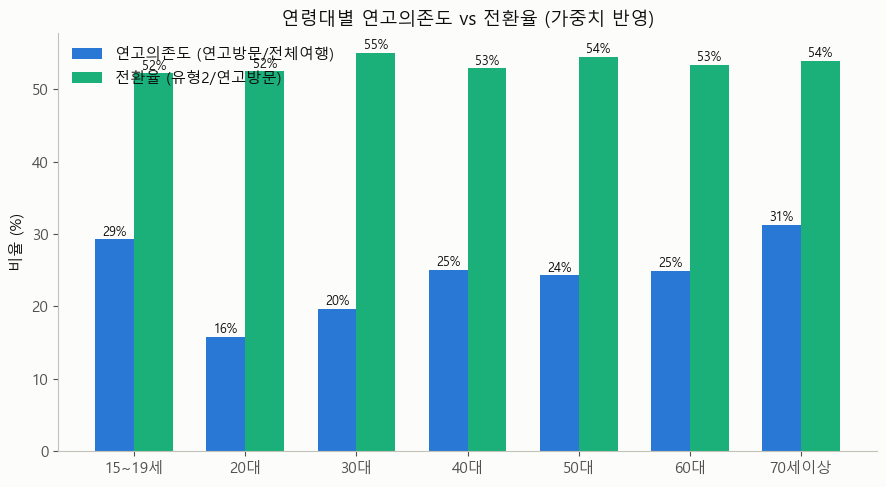

In [36]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(age_tbl))
w = 0.35
ax.bar(x - w/2, age_tbl['연고의존도'], width=w, color=CAT_COLORS[0], label='연고의존도 (연고방문/전체여행)')
ax.bar(x + w/2, age_tbl['전환율'], width=w, color=CAT_COLORS[1], label='전환율 (유형2/연고방문)')
ax.set_xticks(x)
ax.set_xticklabels(age_tbl.index)
ax.set_ylabel('비율 (%)')
ax.set_title('연령대별 연고의존도 vs 전환율 (가중치 반영)')
ax.legend(frameon=False)
for xi, (dep, conv) in enumerate(zip(age_tbl['연고의존도'], age_tbl['전환율'])):
    ax.text(xi - w/2, dep + 0.5, f'{dep:.0f}%', ha='center', fontsize=9)
    ax.text(xi + w/2, conv + 0.5, f'{conv:.0f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

**해석 포인트**: 연고의존도는 **U자형**이다 — 15~19세(29.3%)와 70세이상(31.3%)에서 가장 높고, 20대(15.8%)에서 가장 낮다. 학업·취업으로
독립하는 2030세대는 순수관광 목적 여행 비중이 상대적으로 크고, 미성년(가족 동반)과 고령층은 명절·경조사 등 연고 방문이 여행의 큰 축을
차지한다는 1.3절의 서사와 부합한다.

반면 **전환율은 52~55%로 연령대 간 차이가 거의 없다** — "나이가 많을수록 관광을 안 붙인다"는 통념과 달리, 일단 연고를 방문하면 관광을
곁들이는 비율 자체는 연령별로 크게 갈리지 않는다. 즉 바우처의 "전환 촉진" 레버는 특정 연령대를 표적화하기보다 6장에서 찾은 **지역** 축이
더 크게 작동할 가능성이 높다. 다만 연고의존도가 높은 10대·고령층은 애초에 "여행 중 연고방문 비중"이 큰 모수이므로, 바우처 도달 채널
(예: 고령층은 오프라인·주변인 채널, 10대는 가족 단위 접근)을 연령별로 달리 설계할 근거는 된다.

In [37]:
behav = trips[trips['CASE'].isin([2, 3])].dropna(subset=['BAGE']).copy()
behav['숙박'] = (behav['숙박여부'] == '숙박').astype(float)

behav_tbl = behav.groupby(['BAGE', 'CASE']).agg(
    표본수=('ID', 'size'),
    평균여행일수=('S_Day', 'mean'),
    평균동반인원=('NUM', 'mean'),
    평균1인지출=('ONE_COST', 'mean'),
    숙박비율=('숙박', 'mean'),
).round(1)
behav_tbl['숙박비율'] = (behav_tbl['숙박비율'] * 100).round(1)
behav_tbl = behav_tbl.rename(index=CASE_LABELS, level='CASE').rename(index=age_labels, level='BAGE')
behav_tbl

표본수  평균여행일수  평균동반인원    평균1인지출  숙박비율
BAGE   CASE                                          
15~19세 2.연고방문+관광  140     0.6     2.7   84171.0  50.0
       3.단순연고방문   114     0.9     2.7   57489.8  50.0
20대    2.연고방문+관광  393     1.1     2.1  124037.2  60.0
       3.단순연고방문   310     0.8     1.8   82215.1  50.0
30대    2.연고방문+관광  615     1.0     2.3  128399.8  60.0
       3.단순연고방문   431     1.0     2.1   93658.1  60.0
40대    2.연고방문+관광  841     1.0     2.8  115467.0  60.0
       3.단순연고방문   596     0.7     2.5   79170.3  50.0
50대    2.연고방문+관광  884     0.8     2.5  126768.8  50.0
       3.단순연고방문   656     0.6     2.2   79898.4  40.0
60대    2.연고방문+관광  688     0.7     2.4  119884.6  50.0
       3.단순연고방문   480     0.5     1.9   86400.3  40.0
70세이상  2.연고방문+관광  416     0.8     2.3   98105.1  50.0
       3.단순연고방문   315     0.7     1.8   73541.8  40.0

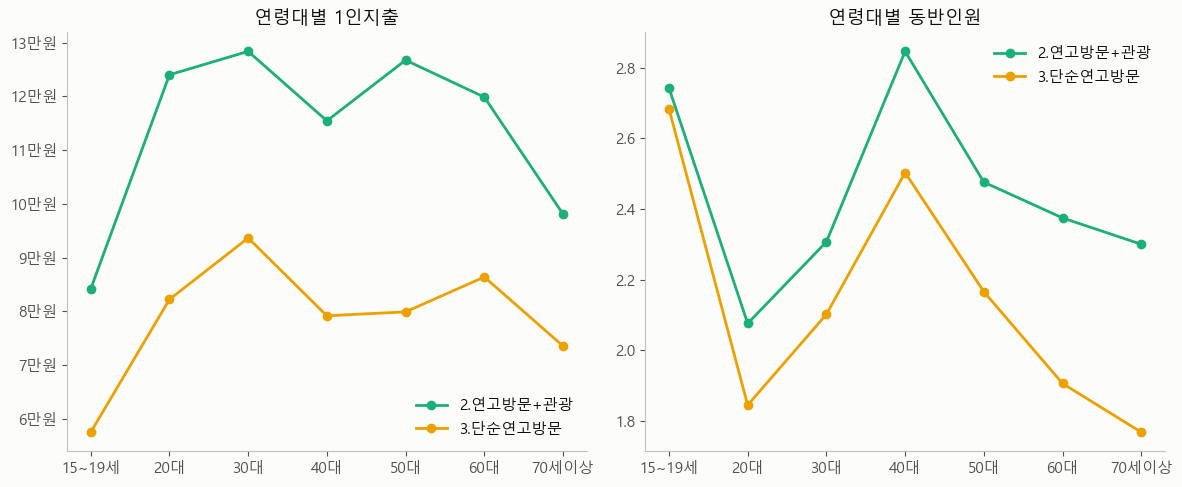

In [38]:
plot_tbl = behav.groupby(['BAGE', 'CASE']).agg(
    평균1인지출=('ONE_COST', 'mean'),
    평균동반인원=('NUM', 'mean'),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for c in [2, 3]:
    sub = plot_tbl[plot_tbl['CASE'] == c].sort_values('BAGE')
    axes[0].plot(sub['BAGE'], sub['평균1인지출'], marker='o', color=CASE_COLORS[c], label=CASE_LABELS[c], linewidth=2)
    axes[1].plot(sub['BAGE'], sub['평균동반인원'], marker='o', color=CASE_COLORS[c], label=CASE_LABELS[c], linewidth=2)

age_keys = sorted(age_labels.keys())
for ax in axes:
    ax.set_xticks(age_keys)
    ax.set_xticklabels([age_labels[k] for k in age_keys])
    ax.legend(frameon=False)

axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e4:,.0f}만원'))
axes[0].set_title('연령대별 1인지출')
axes[1].set_title('연령대별 동반인원')

plt.tight_layout()
plt.show()

**해석 포인트**: 1인지출 격차(유형2−유형3)는 **50대에서 가장 크고(+4.7만원, +59%) 70세이상에서 가장 작다(+2.5만원, +33%)** — 같은
"전환 1건"이라도 연령대에 따라 추가로 끌어내는 소비 규모가 다르다. 동반인원 격차는 반대로 **고령층(60·70대)에서 가장 크다** — 단순방문
시 동반인원은 1.8~1.9명으로 적지만 관광을 붙이면 2.3~2.4명으로 늘어난다(+0.5명 안팎), 즉 고령층의 전환은 가족 단위 동반여행으로
이어질 가능성이 있다. 반면 여행일수 격차는 모든 연령대에서 0~0.3일 수준으로 작다 — 관광 추가가 숙박 연장보다는 **당일 활동 추가**로
이뤄지는 경우가 많다는 뜻이므로, 체험 바우처를 숙박 연계형뿐 아니라 당일 프로그램형으로 설계해도 무리가 없어 보인다.

**정책 함의 요약**: (1) 연령대별 "전환 촉진" 우선순위보다는 6장의 지역 타겟이 더 유효한 레버다. (2) 전환의 경제적 효과(지출 증가폭)를
극대화하려면 50대를, 동반여행 확산(가족 단위 재방문) 효과를 노리려면 60·70대를 우선 타겟으로 고려할 수 있다.